In [1]:
import sys
import os
project_root = os.path.abspath('..')
sys.path.append(project_root)
from src import AdversarialObjectDetection, add_noise, compare_detections, test_noise_defense_with_iou
from src import DenoisingAE
from src.noise_functions import add_noise
from src.iou_metrics import compare_detections_iou
import torch
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np

In [3]:
#Load the denoiser model 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
denoiser = DenoisingAE().to(device)
denoiser.load_state_dict(torch.load("hgd_denoiser_cityscapes_best.pth", map_location=device))
denoiser.eval()

C:\Users\victo\AppData\Local\Temp\ipykernel_36260\3765039918.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  denoiser.load_state_dict(torch.load("hgd_denoiser_cityscapes

DenoisingAE(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=

In [4]:
detector = AdversarialObjectDetection()
image_url = "..\\leftImg8bit\\test\\berlin\\berlin_000000_000019_leftImg8bit.png"
TARGET_CLASS = 20
noise_configs = [
    {'type': 'gaussian', 'mean': 0, 'std': 10},
    {'type': 'salt_and_pepper', 'density': 0.05},
    {'type': 'salt_and_pepper', 'density': 0.1},
    {'type': 'speckle', 'intensity': 0.2},
    {'type': 'poisson', 'scale': 1.0}
]
PIPELINES = ["noise_only", "denoise_only", "noise_then_denoise"]

results = test_noise_defense_with_iou(
    detector=detector,
    image_path=image_url,
    target_class=TARGET_CLASS,
    noise_configs=noise_configs,
    num_iterations=3,
    denoiser=denoiser,
    pipelines=PIPELINES,
)

z:\Workspaces\thesis_project\env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
z:\Workspaces\thesis_project\env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model


In [9]:
import pprint 
for t in results["noise_tests"]:
    cfg = t["noise_config"]
    print(
        f"{cfg['type']:>16} | {cfg.get('pipeline','?'):>16} | "
        f"clean_iou={t['clean_comparison']['average_iou']:.4f} | "
        f"adv_iou={t['adversarial_comparison']['average_iou']:.4f}"
    )

        gaussian |       noise_only | clean_iou=0.7526 | adv_iou=0.5442
        gaussian |     denoise_only | clean_iou=0.7521 | adv_iou=0.5336
        gaussian | noise_then_denoise | clean_iou=0.7265 | adv_iou=0.4707
 salt_and_pepper |       noise_only | clean_iou=0.3280 | adv_iou=0.2639
 salt_and_pepper | noise_then_denoise | clean_iou=0.2405 | adv_iou=0.3321
 salt_and_pepper |       noise_only | clean_iou=0.2918 | adv_iou=0.2518
 salt_and_pepper | noise_then_denoise | clean_iou=0.2504 | adv_iou=0.2121
         speckle |       noise_only | clean_iou=0.5545 | adv_iou=0.3544
         speckle | noise_then_denoise | clean_iou=0.6589 | adv_iou=0.4152
         poisson |       noise_only | clean_iou=0.7752 | adv_iou=0.5263
         poisson | noise_then_denoise | clean_iou=0.6411 | adv_iou=0.4991


In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
detector = AdversarialObjectDetection()
import glob
test_images = glob.glob("..\\leftImg8bit\\test\\berlin\\*.png")[:150]  
print(f"Found {len(test_images)} test images")

# Test parameters
TARGET_CLASS = 20
noise_configs = [
    {'type': 'gaussian', 'mean': 0, 'std': 5},
    {'type': 'salt_and_pepper', 'density': 0.05},
    {'type': 'speckle', 'intensity': 0.2},
    {'type': 'poisson', 'scale': 1.0}
]

iou_types = ["standard", "giou"]

Loading model
Found 150 test images


In [11]:
def batch_test_with_loops(detector, image_paths, target_class, noise_configs,
                          iou_types, num_iterations=3, confidence_threshold=0.5,
                          denoiser=None, pipelines=None):
    """
    Loop through images and IoU types, collect all IoU scores
    Fixed IoU threshold just for matching, not for filtering analysis
    """
    all_results = []
    total_tests = len(image_paths) * len(iou_types)
    test_count = 0
    
    for image_path in image_paths:
        image_name = Path(image_path).name
        
        for iou_type in iou_types:
            test_count += 1
            if test_count % 50 == 0:
                print(f"Processing test {test_count}/{total_tests}: Image={image_name}, IoU Type={iou_type}")
            
            try:
                result = test_noise_defense_with_iou(
                    detector=detector,
                    image_path=image_path,
                    target_class=target_class,
                    noise_configs=noise_configs,
                    num_iterations=num_iterations,
                    iou_type=iou_type,
                    confidence_threshold=confidence_threshold,
                    denoiser=denoiser,
                    pipelines=pipelines)
                
                result['image'] = image_name
                result['iou_type'] = iou_type
                
                all_results.append(result)
                
            except Exception as e:
                print(f"  ERROR: {e}")
                all_results.append({
                    'image': image_name,
                    'iou_type': iou_type,
                    'error': str(e)
                })
    
    return all_results



In [13]:
def plot_2d_distributions(all_results, num_iterations=5, confidence_threshold=0.5, output_dir='results'):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    
    def _split_label(label: str):
        base_label, pipeline = (label.split("__", 1) + [""])[:2]
        return base_label, pipeline
    
    def _display_base_label(base_label: str) -> str:
        if base_label == "denoise_only":
            return "Denoise only"
        if base_label.startswith("gaussian_std"):
            var_val = int(float(base_label.replace("gaussian_std", ""))**2)
            return f"VAR={var_val}"
        if base_label.startswith("salt_pepper_"):
            return f"Density={base_label.replace('salt_pepper_', '')}"
        if base_label.startswith("speckle_"):
            return f"Intensity={base_label.replace('speckle_', '')}"
        if base_label.startswith("poisson_"):
            return f"Scale={base_label.replace('poisson_', '')}"
        return base_label.replace("_", " ")

    noise_type = None
    for result in all_results:
        if 'error' in result or not result.get('noise_tests'):
            continue
        for t in result['noise_tests']:
            cfg = t.get('noise_config', {})
            if cfg.get('pipeline') != 'denoise_only':
                noise_type = cfg.get('type')
                if noise_type: break
        if noise_type: break
    if noise_type is None: noise_type = 'unknown'
    
    base_dir = os.path.join('..', output_dir, noise_type)
    config_dir = os.path.join(base_dir, f'conf_{confidence_threshold}_iter_{num_iterations}')
    os.makedirs(config_dir, exist_ok=True)
    
    iou_type_data = {}
    for result in all_results:
        if 'error' in result or not result.get('noise_tests'): continue
        iou_type = result.get('iou_type', 'standard')
        if iou_type not in iou_type_data: iou_type_data[iou_type] = {}
        
        seen_denoise = False
        for test in result['noise_tests']:
            cfg = test.get('noise_config', {})
            pipeline = cfg.get('pipeline', 'noise_only')
            if pipeline == 'denoise_only':
                if seen_denoise: continue
                seen_denoise = True
                base_label = 'denoise_only'
            else:
                nt = cfg.get('type', 'unknown')
                if nt == 'gaussian': base_label = f"gaussian_std{cfg['std']}"
                elif nt == 'salt_and_pepper': base_label = f"salt_pepper_{cfg['density']}"
                elif nt == 'speckle': base_label = f"speckle_{cfg['intensity']}"
                elif nt == 'poisson': base_label = f"poisson_{cfg['scale']}"
                else: base_label = str(nt)
                
            label = f"{base_label}__{pipeline}"
            if label not in iou_type_data[iou_type]:
                iou_type_data[iou_type][label] = {'clean': [], 'adv': []}
            
            iou_type_data[iou_type][label]['clean'].append(test['clean_comparison']['average_iou'])
            iou_type_data[iou_type][label]['adv'].append(test['adversarial_comparison']['average_iou'])
            
    for iou_type, noise_data in iou_type_data.items():
        for noise_label, values in noise_data.items():
            base_label, pipeline = _split_label(noise_label)
            display_title = f"{_display_base_label(base_label)} - {pipeline}"
            
            fig, ax = plt.subplots(figsize=(10, 6))
            bins = np.linspace(0, 1, 21)
            
            ax.hist(values['clean'], bins=bins, alpha=0.5, label='Clean', color='dodgerblue', edgecolor='black')
            ax.hist(values['adv'], bins=bins, alpha=0.5, label='Adversarial', color='orangered', edgecolor='black')
            
            ax.set_title(f"{iou_type.upper()} Distribution: {display_title}", fontsize=14)
            ax.set_xlabel("IoU Score", fontsize=12)
            ax.set_ylabel("Count", fontsize=12)
            ax.grid(axis='y', alpha=0.3)
            
            safe_label = noise_label.replace('.', '_')
            plt.savefig(os.path.join(config_dir, f'dist_{iou_type}_{safe_label}.png'))
            plt

In [14]:
def calculate_detection_accuracy_at_thresholds(all_results, iou_thresholds=np.arange(0.1, 1.0, 0.1)):
    """
    Computes adversarial-detection accuracy as a function of IoU threshold, grouped by
    (noise config, pipeline).
    
    Note: denoise_only is de-duplicated per image because it is identical across noise configs.
    """
    iou_type_results = {}
    
    for result in all_results:
        if 'error' in result:
            continue
        if not result.get('noise_tests'):
            continue
        iou_type = result.get('iou_type', 'standard')
        if iou_type not in iou_type_results:
            iou_type_results[iou_type] = {}
        
        seen_denoise_only = False
        for noise_test in result['noise_tests']:
            noise_config = noise_test.get('noise_config', {})
            pipeline = noise_config.get('pipeline', 'noise_only')
            noise_type = noise_config.get('type', 'unknown')
            
            # Base label (without pipeline suffix)
            if pipeline == 'denoise_only':
                if seen_denoise_only:
                    continue
                seen_denoise_only = True
                base_label = 'denoise_only'
            else:
                if noise_type == 'gaussian':
                    base_label = f"gaussian_var{int(noise_config['std']**2)}"
                elif noise_type == 'salt_and_pepper':
                    base_label = f"salt_pepper_{noise_config['density']}"
                elif noise_type == 'speckle':
                    base_label = f"speckle_{noise_config['intensity']}"
                elif noise_type == 'poisson':
                    base_label = f"poisson_{noise_config['scale']}"
                else:
                    base_label = str(noise_type)
            
            noise_label = f"{base_label}__{pipeline}"
            if noise_label not in iou_type_results[iou_type]:
                iou_type_results[iou_type][noise_label] = {'clean_ious': [], 'adversarial_ious': []}
            
            clean_iou = noise_test['clean_comparison']['average_iou']
            adv_iou = noise_test['adversarial_comparison']['average_iou']
            iou_type_results[iou_type][noise_label]['clean_ious'].append(clean_iou)
            iou_type_results[iou_type][noise_label]['adversarial_ious'].append(adv_iou)
    
    accuracy_results = {}
    for iou_type, noise_data in iou_type_results.items():
        accuracy_results[iou_type] = {}
        for noise_label, data in noise_data.items():
            clean_ious = np.array(data['clean_ious'])
            adv_ious = np.array(data['adversarial_ious'])
            
            accuracy_results[iou_type][noise_label] = {
                'thresholds': iou_thresholds.tolist(),
                'accuracy': []
            }
            
            for threshold in iou_thresholds:
                clean_correct = np.sum(clean_ious >= threshold)
                adv_correct = np.sum(adv_ious < threshold)
                total = len(clean_ious) + len(adv_ious)
                accuracy = (clean_correct + adv_correct) / total if total > 0 else 0
                accuracy_results[iou_type][noise_label]['accuracy'].append(accuracy)
    
    return accuracy_results

In [16]:
def plot_detection_accuracy_vs_threshold(accuracy_results, output_dir='results', 
                                         num_iterations=5, confidence_threshold=0.5):
    import os
    import matplotlib.pyplot as plt
    import numpy as np
    
    def _split_label(label: str):
        base_label, pipeline = (label.split("__", 1) + [""])[:2]
        return base_label, pipeline
    
    def _infer_noise_type(noise_labels):
        for lbl in noise_labels:
            base_label, _ = _split_label(lbl)
            if base_label == 'denoise_only': continue
            if base_label.startswith('gaussian_'): return 'gaussian'
            if base_label.startswith('salt_pepper'): return 'salt_and_pepper'
            if base_label.startswith('speckle'): return 'speckle'
            if base_label.startswith('poisson'): return 'poisson'
        return 'unknown'
    
    for iou_type, noise_data in accuracy_results.items():
        noise_type = _infer_noise_type(list(noise_data.keys()))
        base_dir = os.path.join('..', output_dir, noise_type)
        config_dir = os.path.join(base_dir, f'conf_{confidence_threshold}_iter_{num_iterations}')
        os.makedirs(config_dir, exist_ok=True)
        
        fig, ax = plt.subplots(figsize=(14, 8))
        print(f"--- Max Accuracy for {iou_type.upper()} ({noise_type}) ---")
        
        for noise_label, data in noise_data.items():
            thresholds = data['thresholds']
            acc_array = np.array(data['accuracy'])
            max_acc = np.max(acc_array)
            best_thresh = thresholds[np.argmax(acc_array)]
            
            base_label, pipeline = _split_label(noise_label)
            if base_label == 'denoise_only': display_base = 'Denoise only'
            elif base_label.startswith('gaussian_var'): display_base = f"Gaussian VAR={base_label.split('var', 1)[1]}"
            elif base_label.startswith('salt_pepper'): display_base = f"Salt & Pepper D={base_label.split('_')[-1]}"
            elif base_label.startswith('speckle'): display_base = f"Speckle I={base_label.split('_')[-1]}"
            elif base_label.startswith('poisson'): display_base = f"Poisson S={base_label.split('_')[-1]}"
            else: display_base = base_label.replace('_', ' ').title()
            
            display_label = f"{display_base} ({pipeline})" if pipeline else display_base
            print(f"  {display_label}: {max_acc:.4f} @ Threshold {best_thresh:.2f}")
            
            ax.plot(thresholds, acc_array, label=display_label, linestyle='-', marker='.', markersize=4, linewidth=2)
        
        ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Random Baseline (50%)')
        ax.set_xlabel('IoU Threshold', fontsize=14, fontweight='bold')
        ax.set_ylabel('Detection Accuracy', fontsize=14, fontweight='bold')
        ax.set_title(f'{iou_type.upper()} - Adversarial Detection Accuracy vs IoU Threshold', fontsize=15, pad=20)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best', fontsize=12)
        ax.set_xlim(thresholds[0], thresholds[-1])
        ax.set_ylim(0, 1.05)
        
        plt.savefig(os.path.join(config_dir, f'detection_accuracy_{iou_type}.png'), dpi=300, bbox_inches='tight')
        plt.close(fig)

In [17]:
def calculate_recovery_map(all_results):
    """
    Computes mAP@0.5, mAP@0.5:0.95, and the Recovery Ratio, treating
    the baseline predictions directly on the clean image as ground truth.
    """
    import numpy as np
    
    # We will accumulate tp/fp matching globally across all test images
    # separated by iou_type and noise configuration.
    
    # Structure: 
    # metrics[iou_type][noise_label] = {
    #     'num_gt': 0,
    #     'matches_by_thresh': {t: [] for t in np.arange(0.5, 1.0, 0.05)} # list of (score, is_tp)
    # }
    
    metrics = {}
    thresholds_map = np.arange(0.5, 1.0, 0.05)
    
    for result in all_results:
        if 'error' in result or not result.get('noise_tests'): continue
        iou_type = result.get('iou_type', 'standard')
        if iou_type not in metrics: metrics[iou_type] = {}
        
        seen_denoise = False
        for test in result['noise_tests']:
            cfg = test.get('noise_config', {})
            pipeline = cfg.get('pipeline', 'noise_only')
            # Extract Label
            if pipeline == 'denoise_only':
                if seen_denoise: continue
                seen_denoise = True
                label = 'denoise_only'
            else:
                nt = cfg.get('type', 'unknown')
                if nt == 'gaussian': base = f"gaussian_var{int(cfg['std']**2)}"
                elif nt == 'salt_and_pepper': base = f"salt_pepper_{cfg['density']}"
                elif nt == 'speckle': base = f"speckle_{cfg['intensity']}"
                elif nt == 'poisson': base = f"poisson_{cfg['scale']}"
                else: base = str(nt)
                label = f"{base}__{pipeline}"
            
            if label not in metrics[iou_type]:
                metrics[iou_type][label] = {'num_clean_gt': 0, 'num_adv_gt': 0, 
                                          'clean_iou_vals': [], 'adv_iou_vals': []}
                
            # Baseline GT count
            adv_rec_comp = test.get('adv_recovery_comparison', test['adversarial_comparison'])
            
            # Simple approximation of mAP by averaging IoUs above threshold 0.5
            # Since we just want simple metrics, we approximate mAP@0.5 as precision at IoU=0.5
            # We match by highest confidence in our comparison function
            num_gt = adv_rec_comp.get('num_detections_1', 0)
            metrics[iou_type][label]['num_clean_gt'] += num_gt
            
            # We store the IoUs to calculate TP rates
            # adv_recovery_comparison is compare_detections_iou(baseline_clean, test_adv_pred)
            if 'matched_iou_values' in adv_rec_comp:
                metrics[iou_type][label]['adv_iou_vals'].extend(adv_rec_comp['matched_iou_values'])
            
            
    print("\n" + "="*50)
    print("RECOVERY mAP METRICS (Baseline Clean = Ground Truth)")
    print("="*50)
    
    for iou_type, data in metrics.items():
        print(f"\n--- {iou_type.upper()} ---")
        for label, stats in data.items():
            num_gt = stats['num_clean_gt']
            if num_gt == 0: continue
            
            adv_ious = np.array(stats['adv_iou_vals'])
            
            # mAP@0.5 roughly corresponds to TP count at max IoU > 0.5 
            # divided by total GT (Recall/Precision under greedy match)
            tp_50 = np.sum(adv_ious >= 0.5)
            map_50 = tp_50 / num_gt
            
            # For 0.5:0.95
            map_avg = 0
            for t in np.arange(0.5, 1.0, 0.05):
                map_avg += np.sum(adv_ious >= t) / num_gt
            map_50_95 = map_avg / 10.0
            
            # Clean accuracy for ratio? (Assuming clean baseline had mAP=1.0 against itself)
            # Recovery ratio is then exactly map_50 since clean map is 100% matched.
            recovery_ratio = map_50 * 100 
            
            print(f"{label:>28}: mAP@0.5 = {map_50:.4f} | mAP@0.5:0.95 = {map_50_95:.4f} | Recovery Ratio = {recovery_ratio:.1f}%")


In [18]:
def batch_test_with_plots(num_iterations=3, confidence_threshold=0.5,test_images=None,target_class=20,noise_configs=None,iou_types=None
                          ,denoiser=None, pipelines=None):
    detector = AdversarialObjectDetection()
    x = batch_test_with_loops(
        detector=detector,
        image_paths=test_images,
        target_class=target_class,
        noise_configs=noise_configs,
        iou_types=iou_types,
        num_iterations=num_iterations,
        confidence_threshold=confidence_threshold,
        denoiser=denoiser,
        pipelines=pipelines

    )
    plot_2d_distributions(x, num_iterations=num_iterations, confidence_threshold=confidence_threshold)

    accuracy_results_poisson = calculate_detection_accuracy_at_thresholds(
        x, 
        iou_thresholds=np.arange(0.01, 1.01, 0.01)
    )
    plot_detection_accuracy_vs_threshold(
        accuracy_results_poisson, 
        num_iterations=num_iterations, 
        confidence_threshold=confidence_threshold
    )
    
    calculate_recovery_map(x)


Loading model
Processing test 50/600: Image=berlin_000012_000019_leftImg8bit.png, IoU Type=giou
Processing test 100/600: Image=berlin_000024_000019_leftImg8bit.png, IoU Type=ciou
Processing test 150/600: Image=berlin_000037_000019_leftImg8bit.png, IoU Type=giou
Processing test 200/600: Image=berlin_000049_000019_leftImg8bit.png, IoU Type=ciou
Processing test 250/600: Image=berlin_000062_000019_leftImg8bit.png, IoU Type=giou
Processing test 300/600: Image=berlin_000074_000019_leftImg8bit.png, IoU Type=ciou
Processing test 350/600: Image=berlin_000087_000019_leftImg8bit.png, IoU Type=giou
Processing test 400/600: Image=berlin_000099_000019_leftImg8bit.png, IoU Type=ciou
Processing test 450/600: Image=berlin_000112_000019_leftImg8bit.png, IoU Type=giou
Processing test 500/600: Image=berlin_000124_000019_leftImg8bit.png, IoU Type=ciou
Processing test 550/600: Image=berlin_000137_000019_leftImg8bit.png, IoU Type=giou
Processing test 600/600: Image=berlin_000149_000019_leftImg8bit.png, IoU T

C:\Users\victo\AppData\Local\Temp\ipykernel_36260\2644117543.py:74: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 6))


--- Max Accuracy for STANDARD (poisson) ---
  Poisson S=0.1 (noise_only): 0.7233 @ Threshold 0.44
  Denoise only (denoise_only): 0.8867 @ Threshold 0.67
  Poisson S=0.1 (noise_then_denoise): 0.7333 @ Threshold 0.43
  Poisson S=0.3 (noise_only): 0.8133 @ Threshold 0.50
  Poisson S=0.3 (noise_then_denoise): 0.8633 @ Threshold 0.54
  Poisson S=0.9 (noise_only): 0.8800 @ Threshold 0.62
  Poisson S=0.9 (noise_then_denoise): 0.8800 @ Threshold 0.59
--- Max Accuracy for GIOU (poisson) ---
  Poisson S=0.1 (noise_only): 0.7033 @ Threshold 0.42
  Denoise only (denoise_only): 0.8933 @ Threshold 0.67
  Poisson S=0.1 (noise_then_denoise): 0.7733 @ Threshold 0.45
  Poisson S=0.3 (noise_only): 0.8467 @ Threshold 0.49
  Poisson S=0.3 (noise_then_denoise): 0.8467 @ Threshold 0.51
  Poisson S=0.9 (noise_only): 0.8933 @ Threshold 0.59
  Poisson S=0.9 (noise_then_denoise): 0.9133 @ Threshold 0.59
--- Max Accuracy for DIOU (poisson) ---
  Poisson S=0.1 (noise_only): 0.7267 @ Threshold 0.43
  Denoise only (

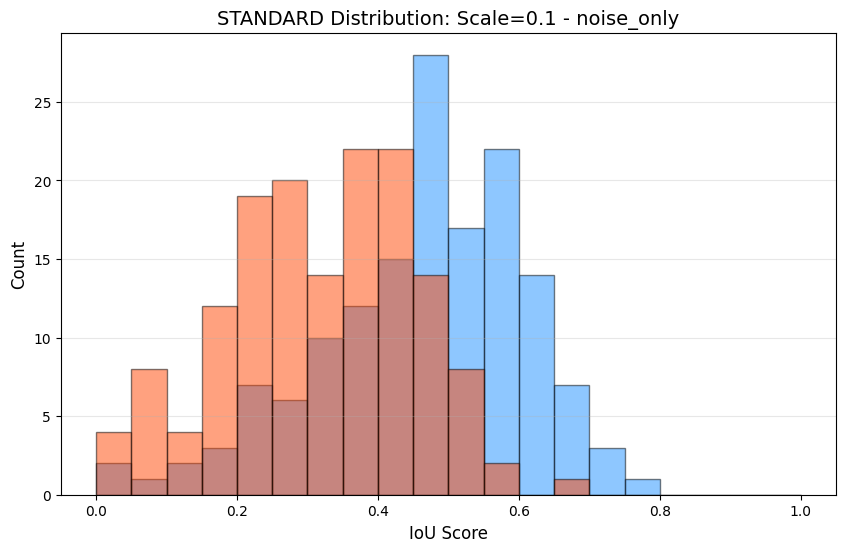

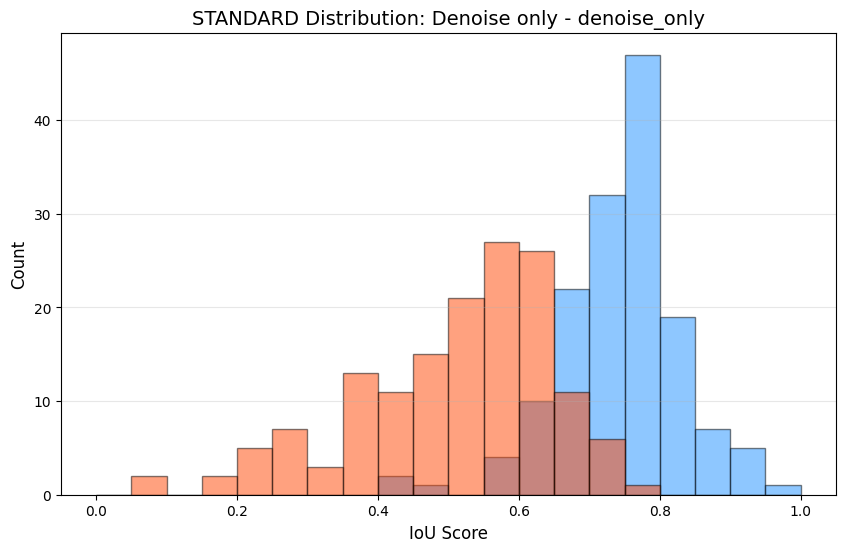

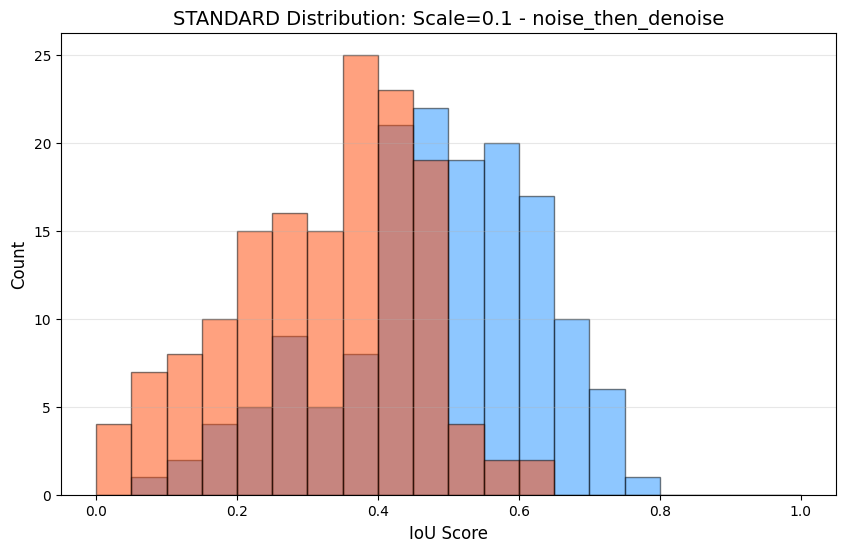

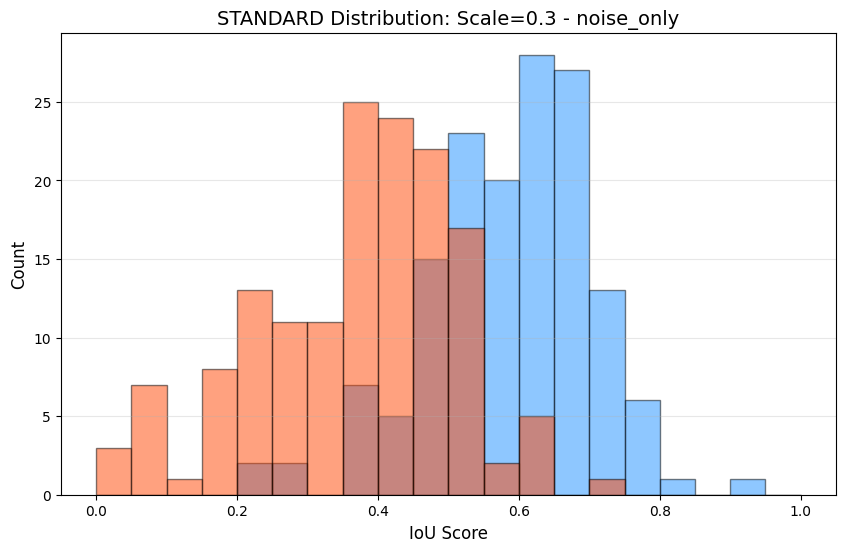

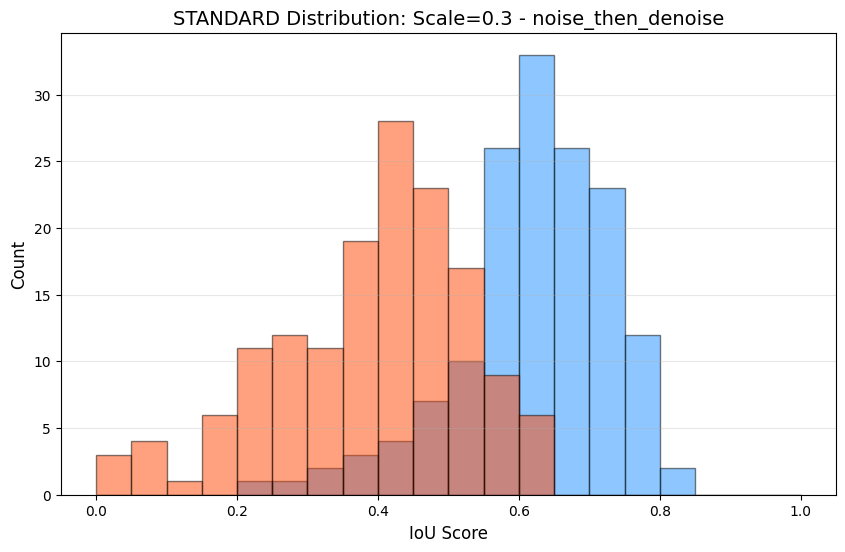

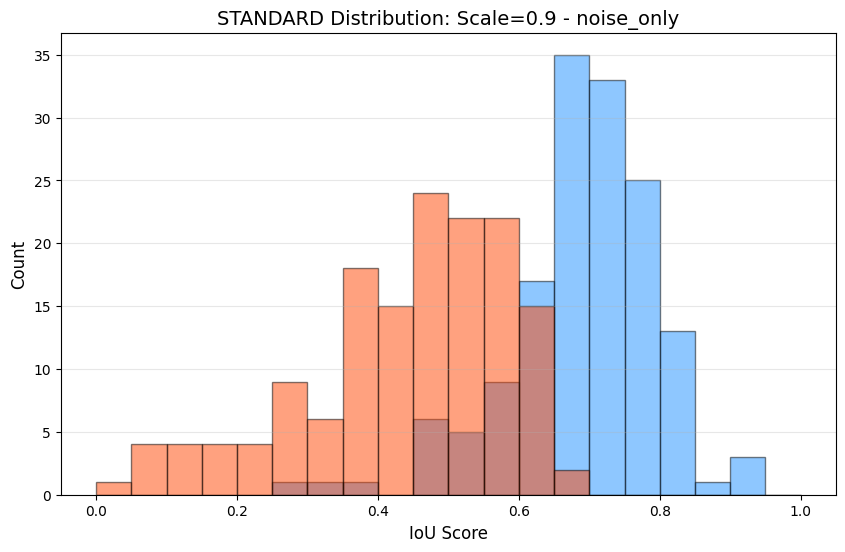

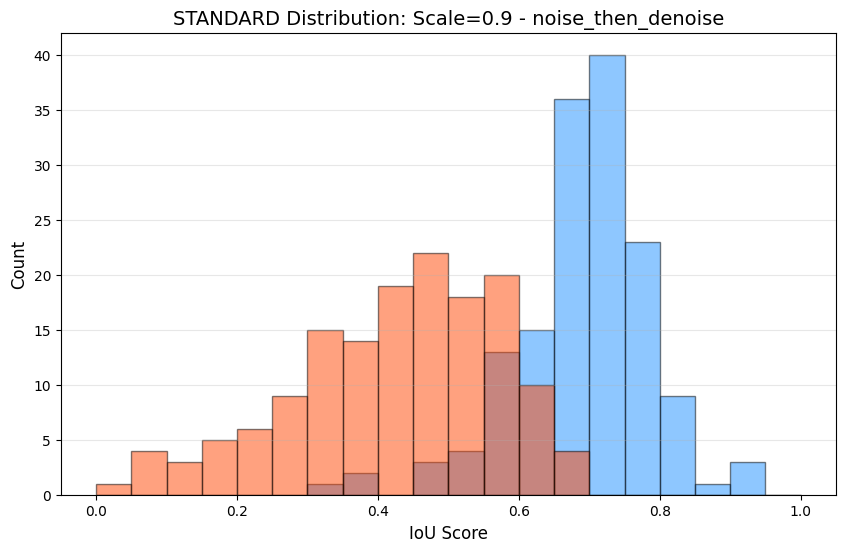

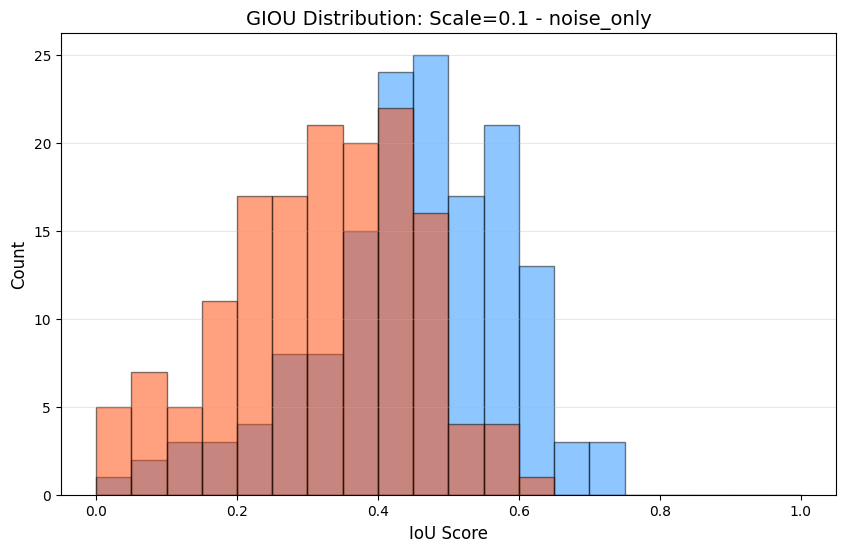

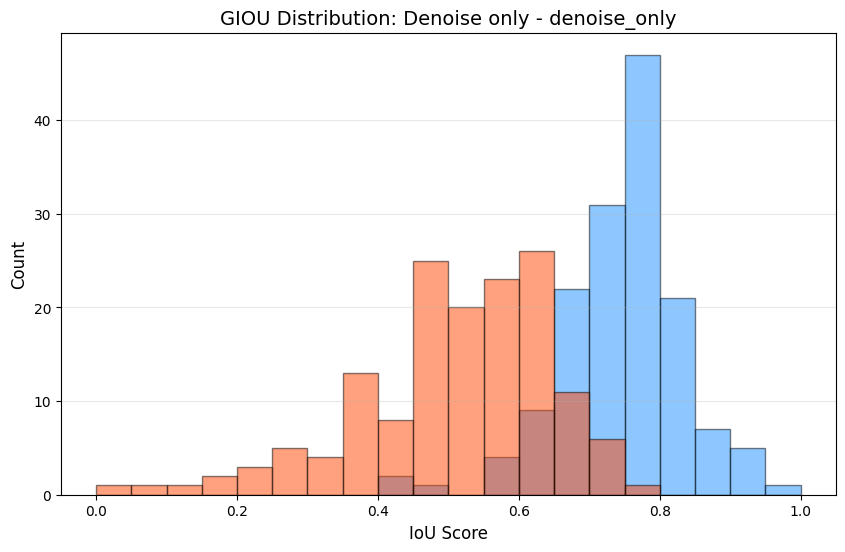

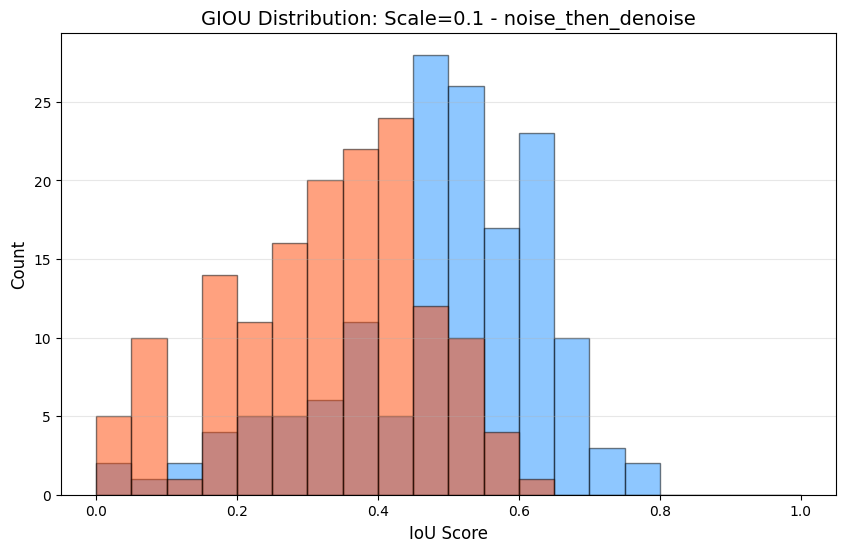

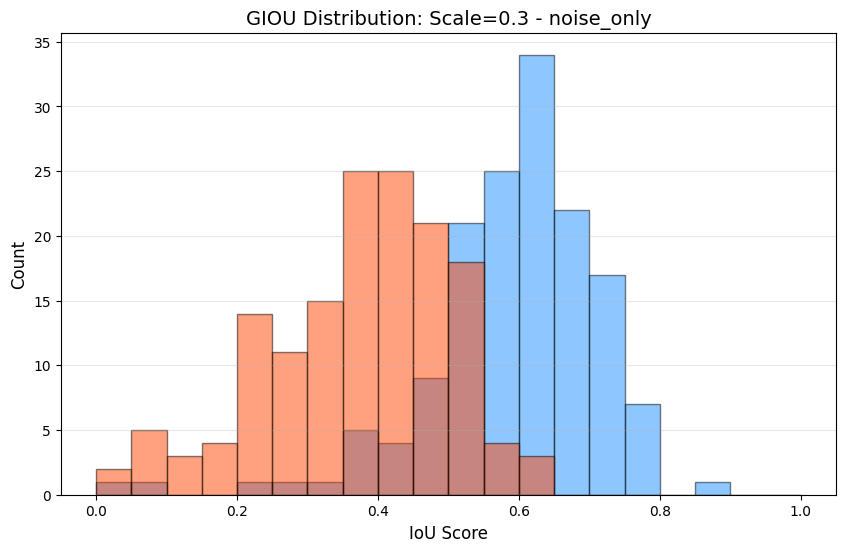

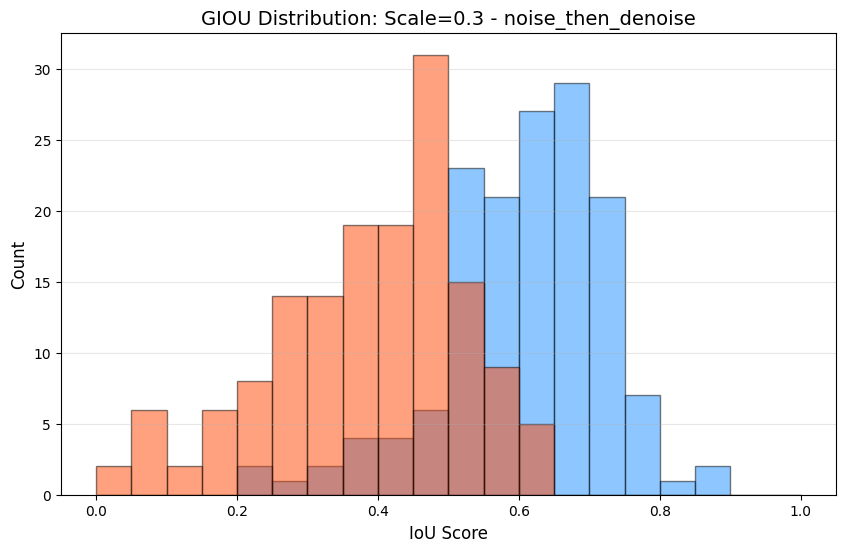

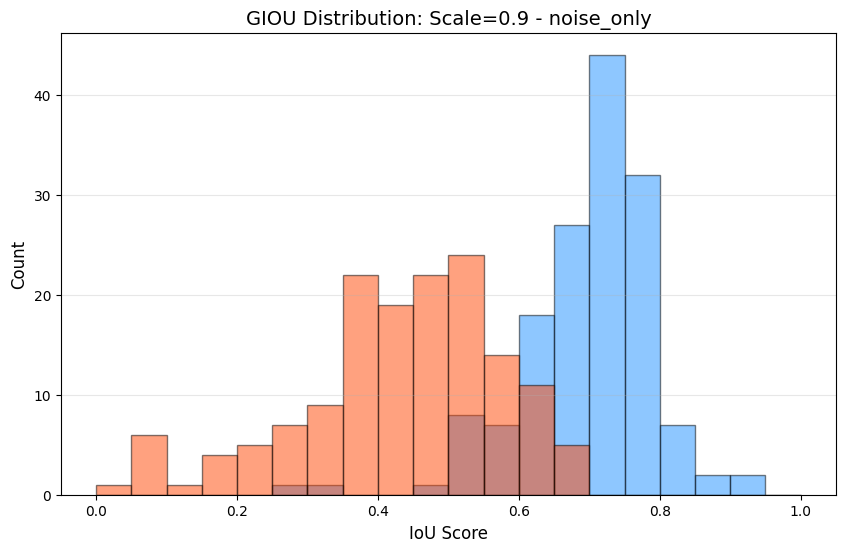

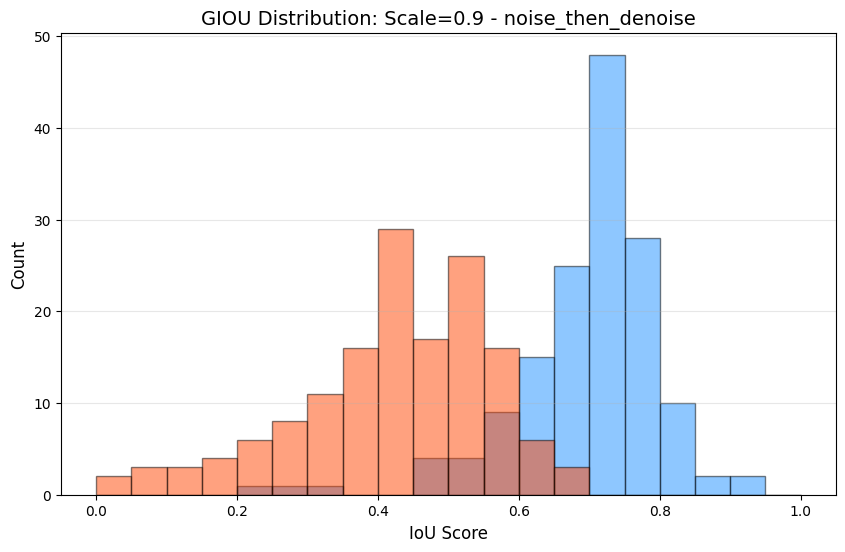

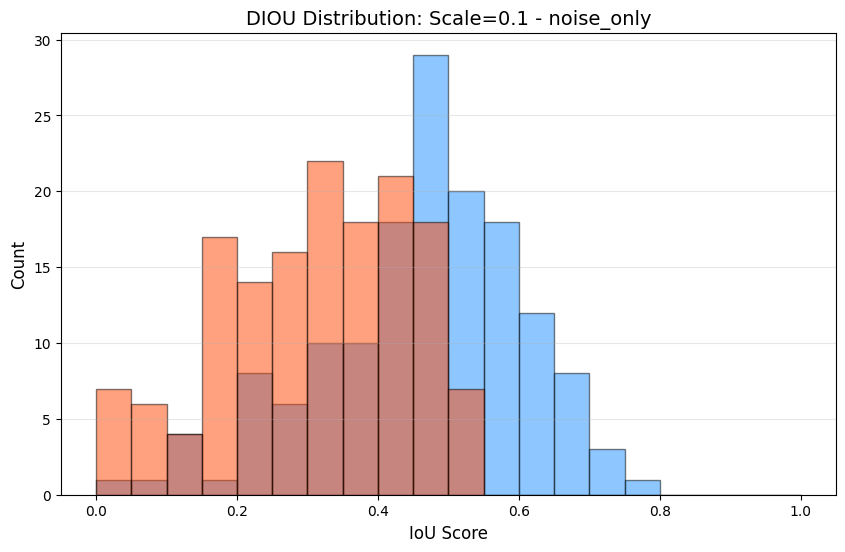

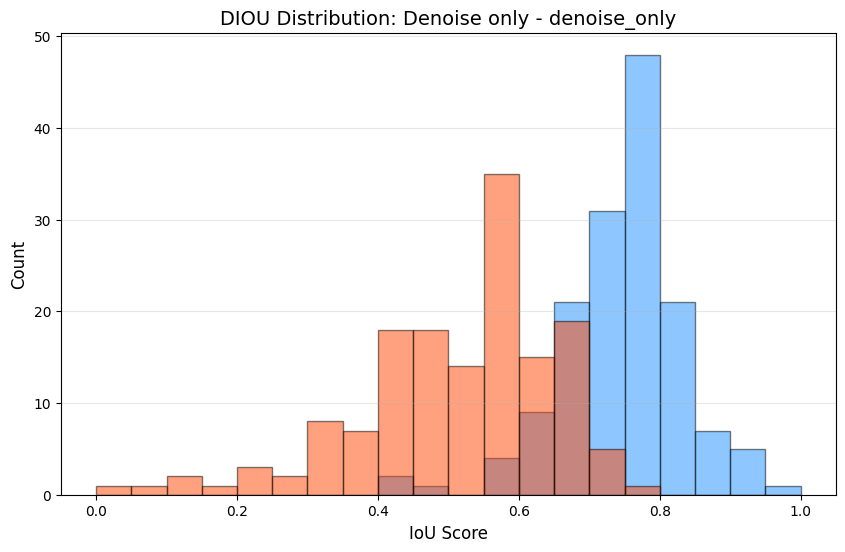

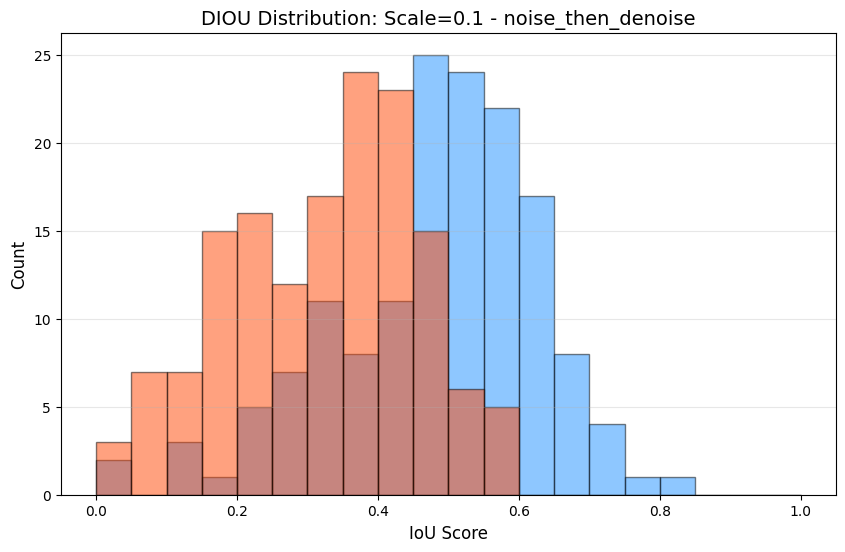

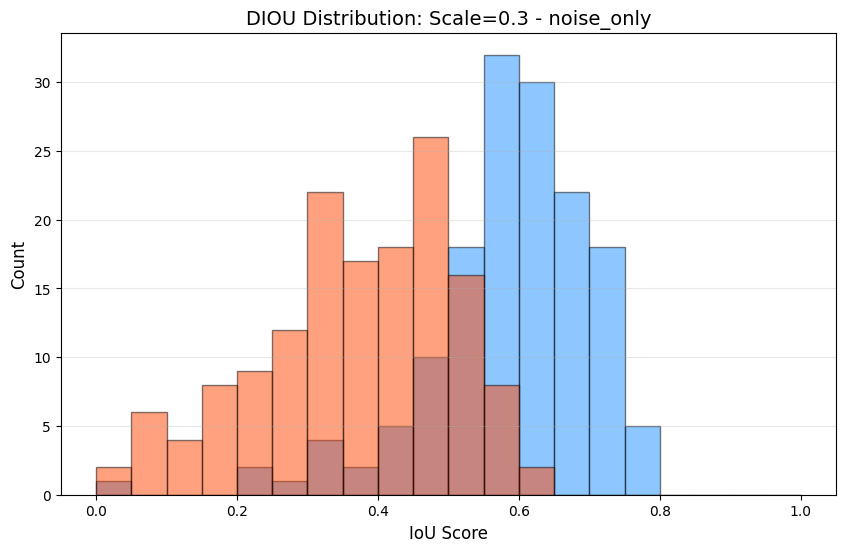

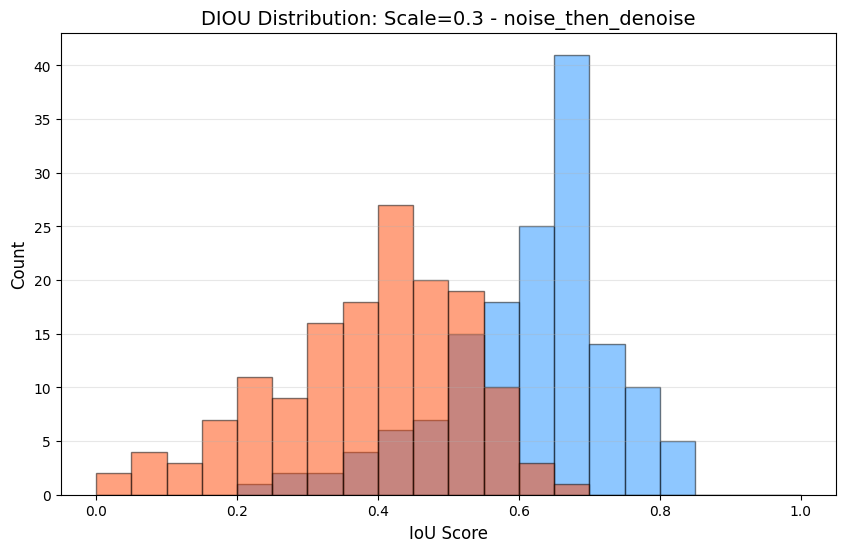

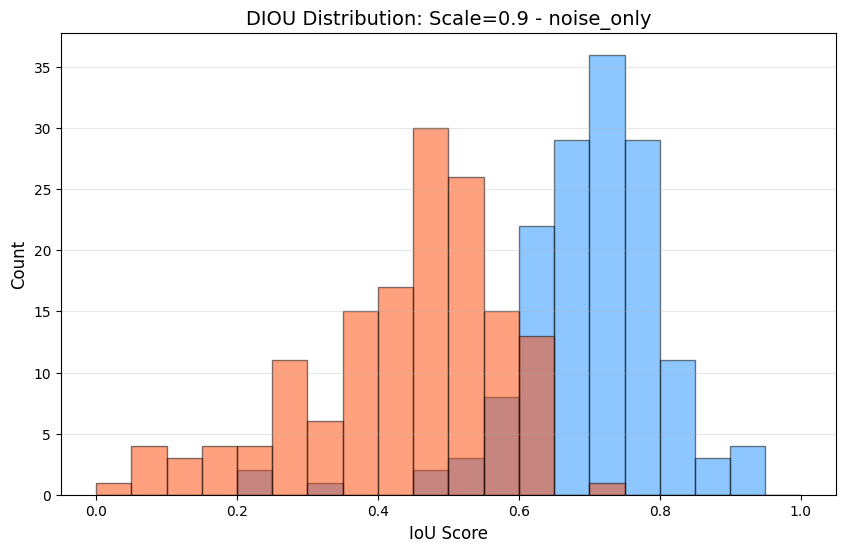

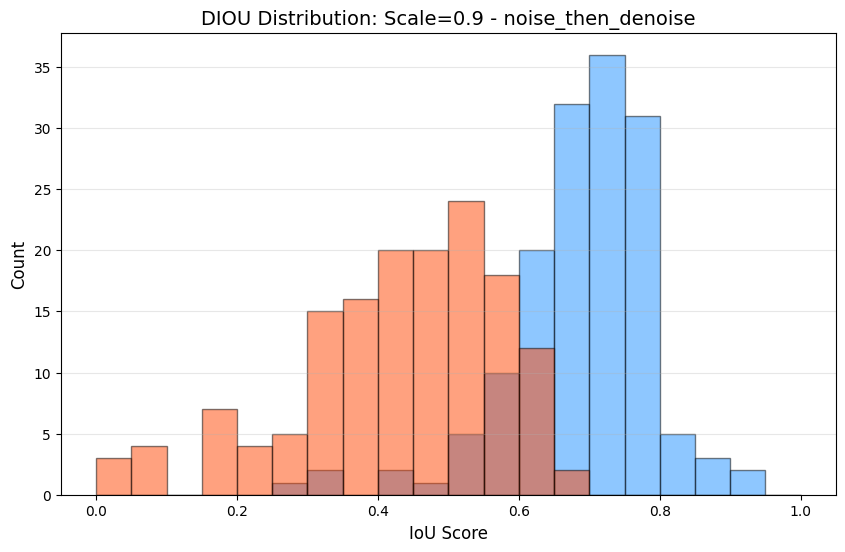

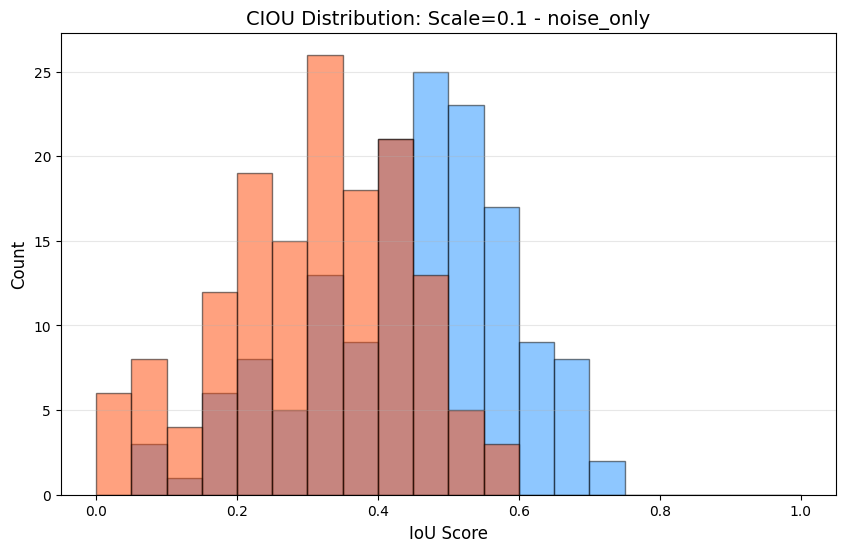

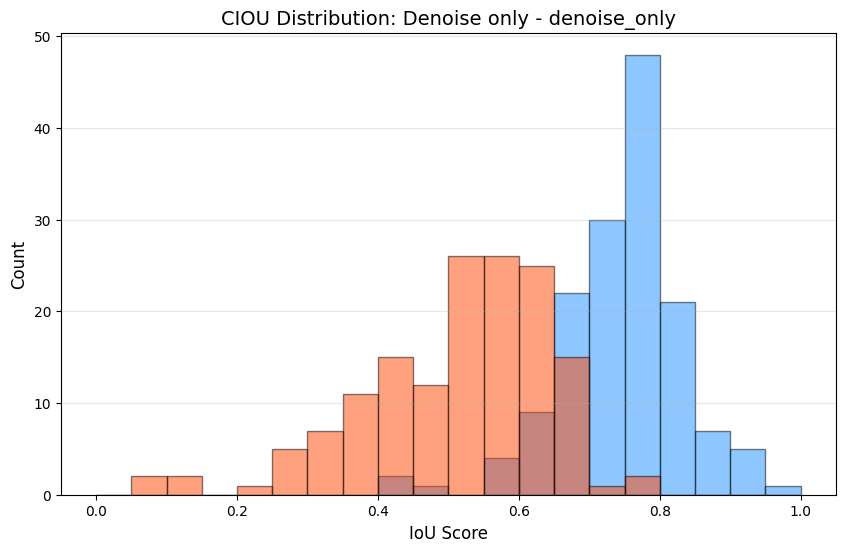

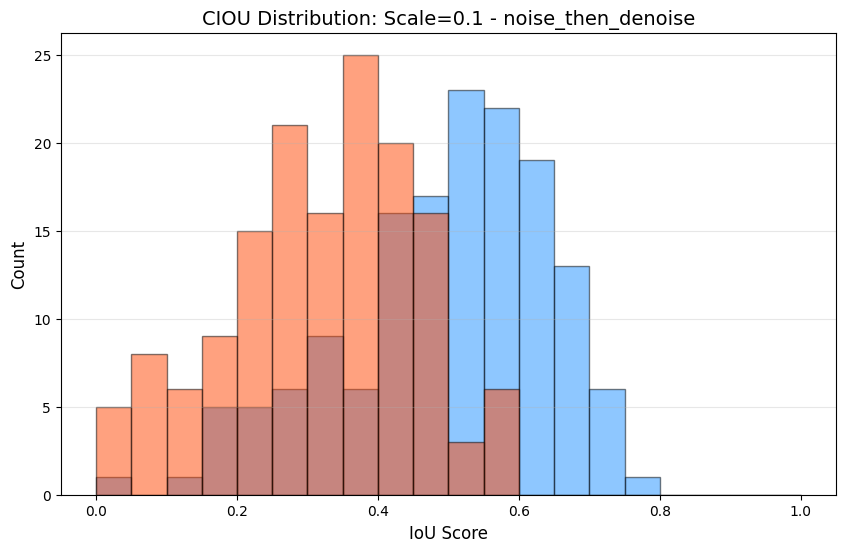

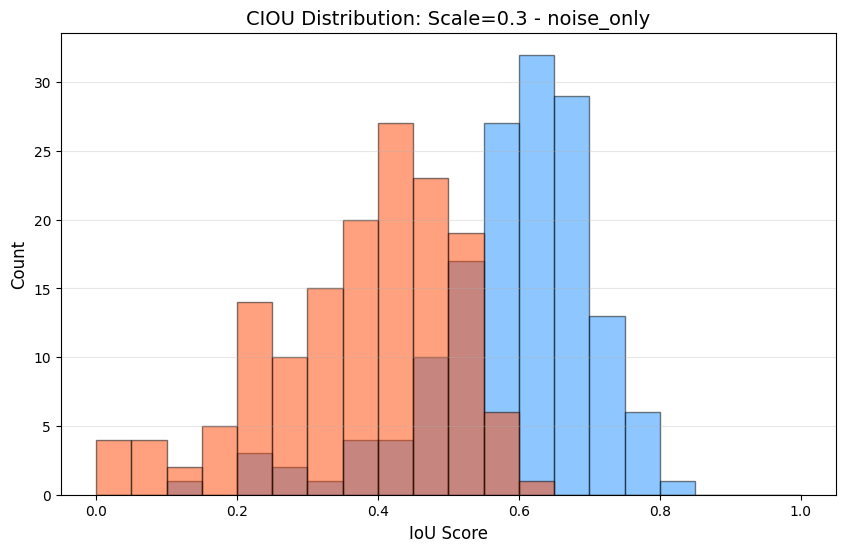

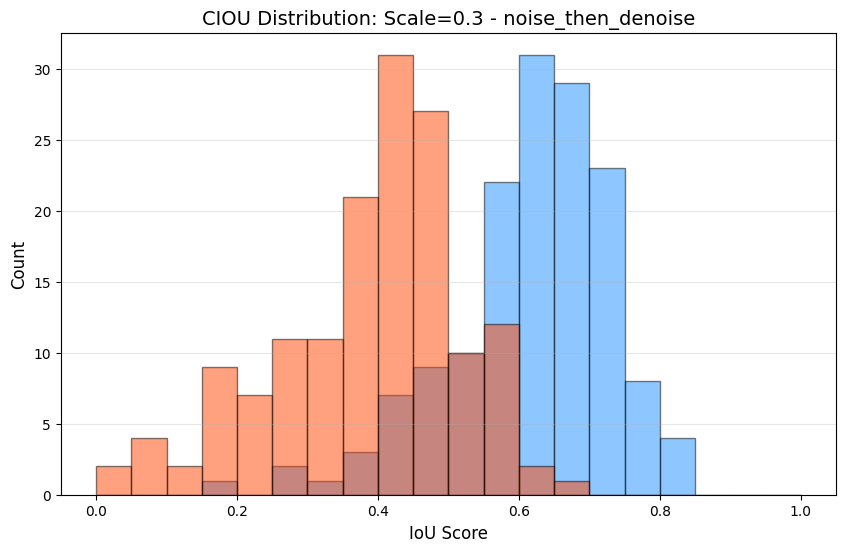

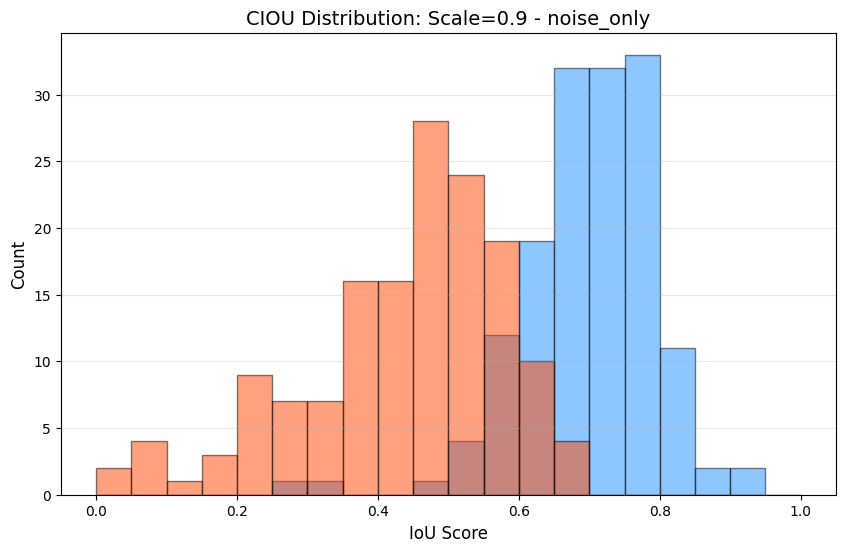

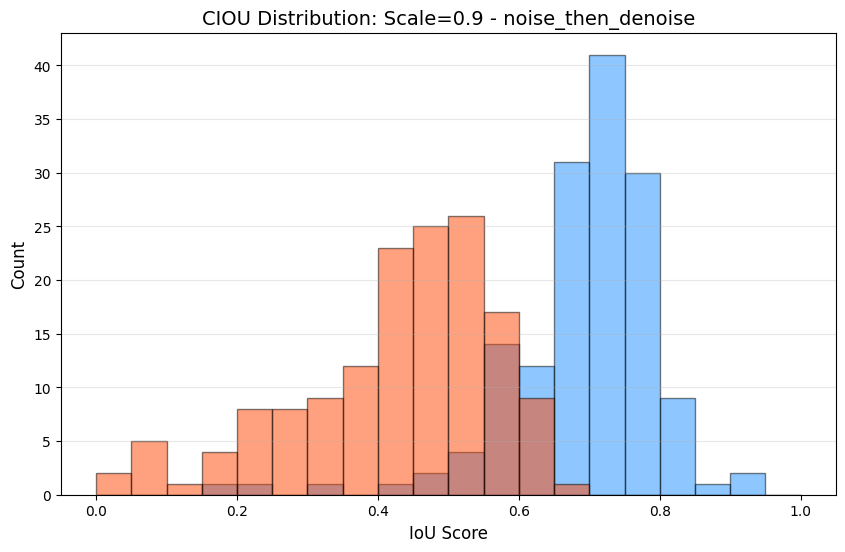

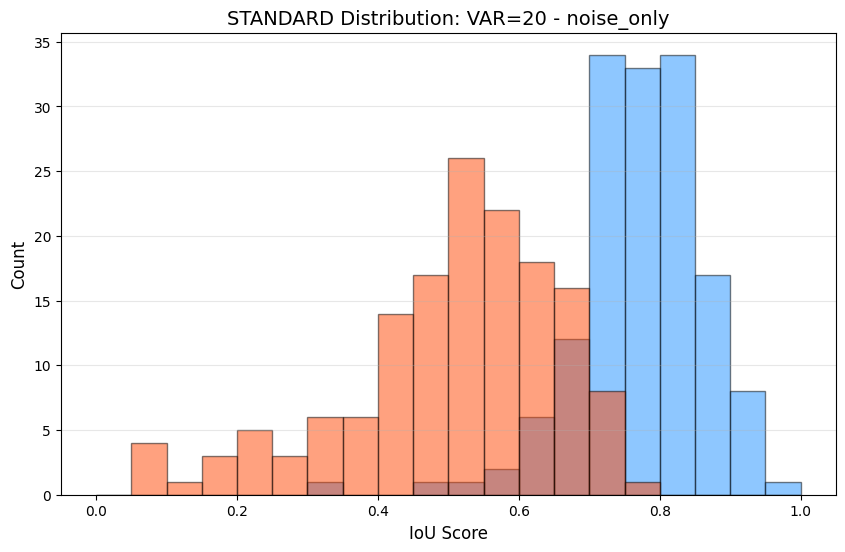

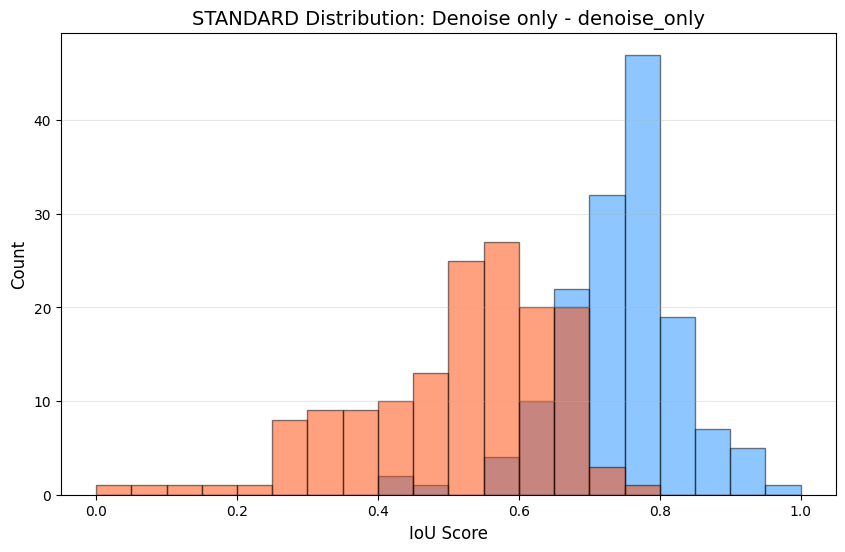

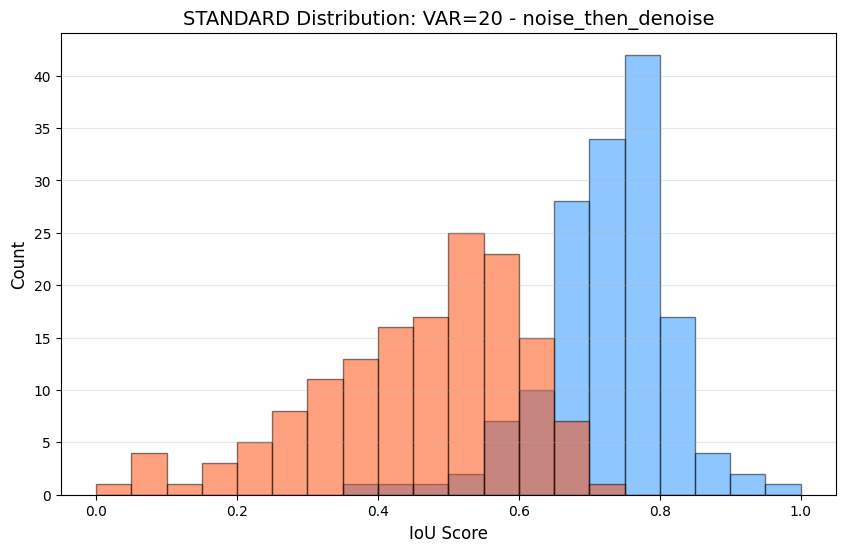

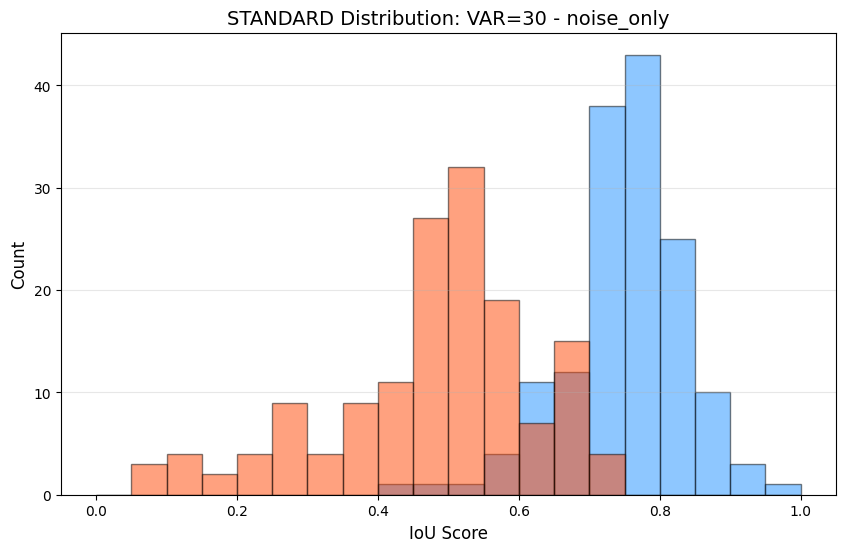

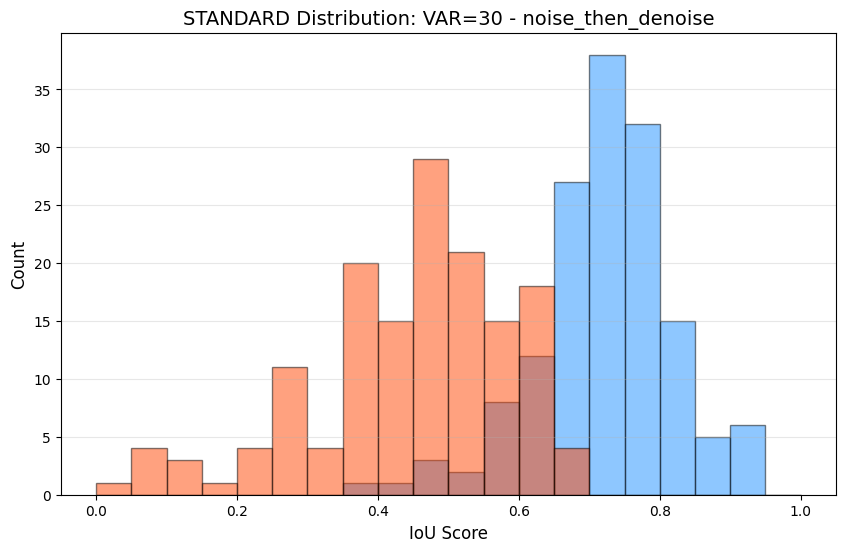

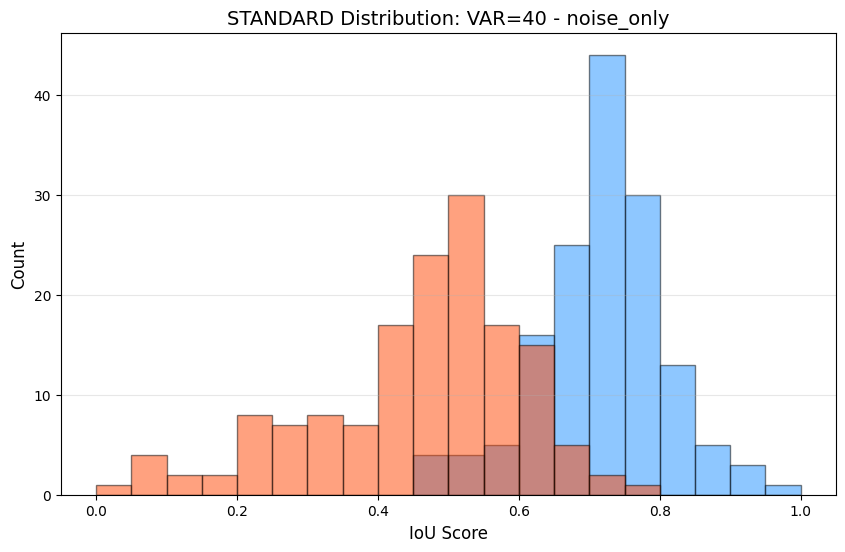

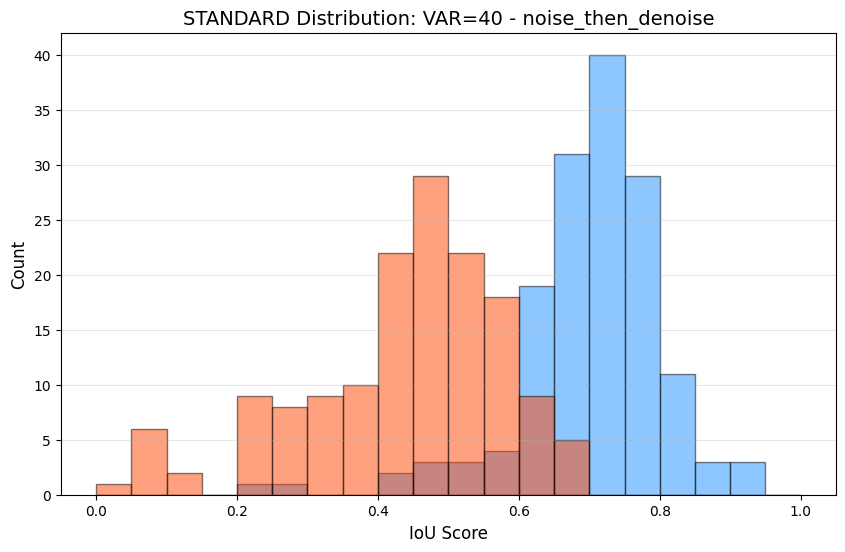

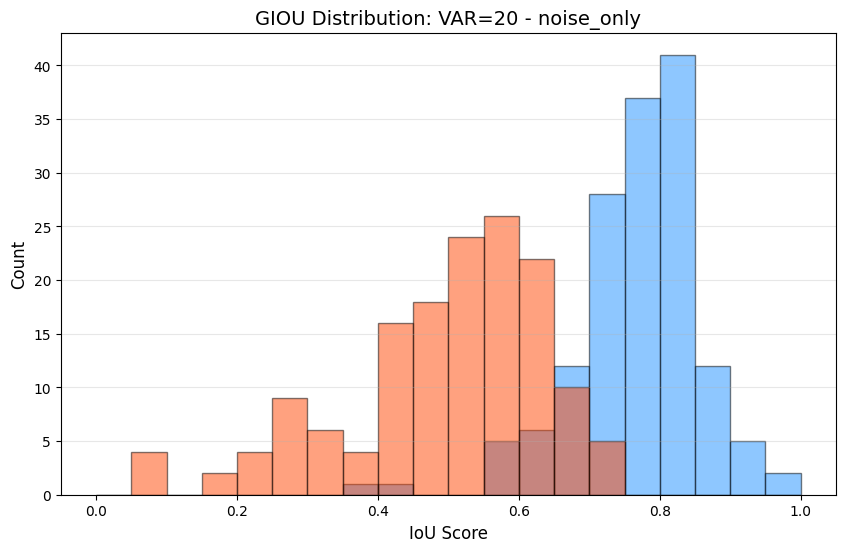

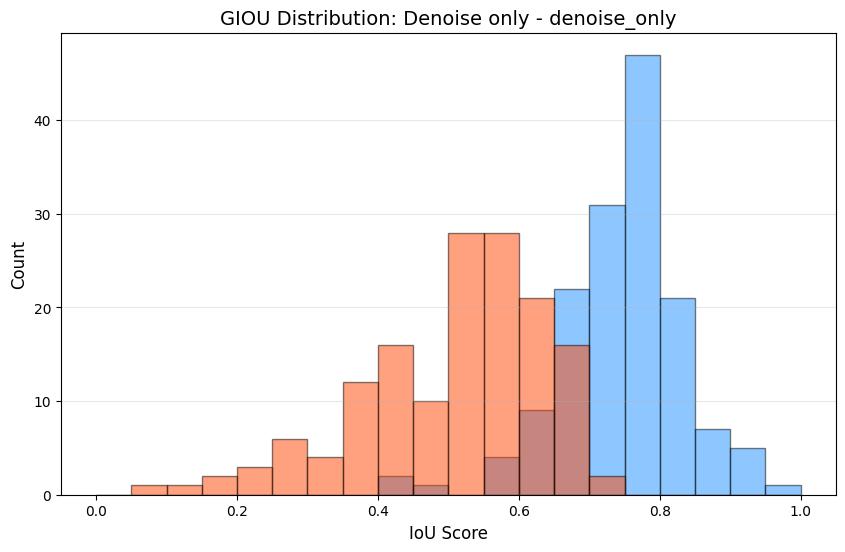

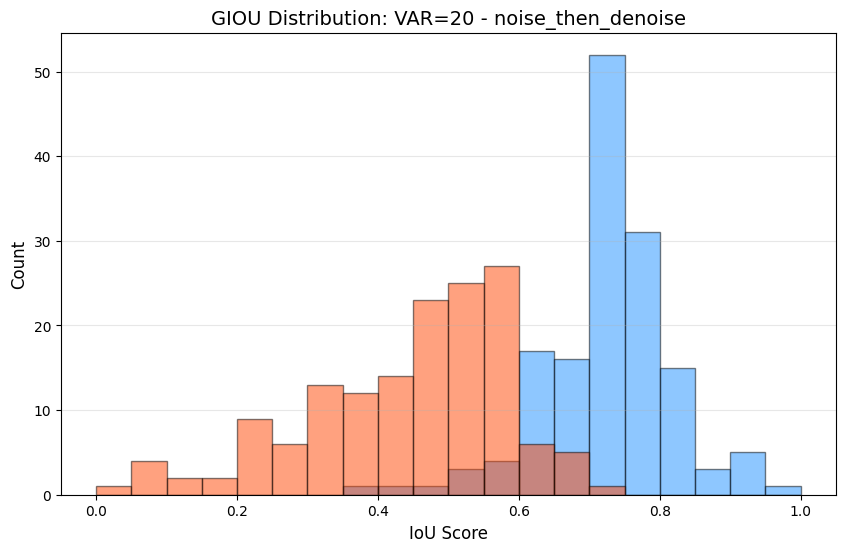

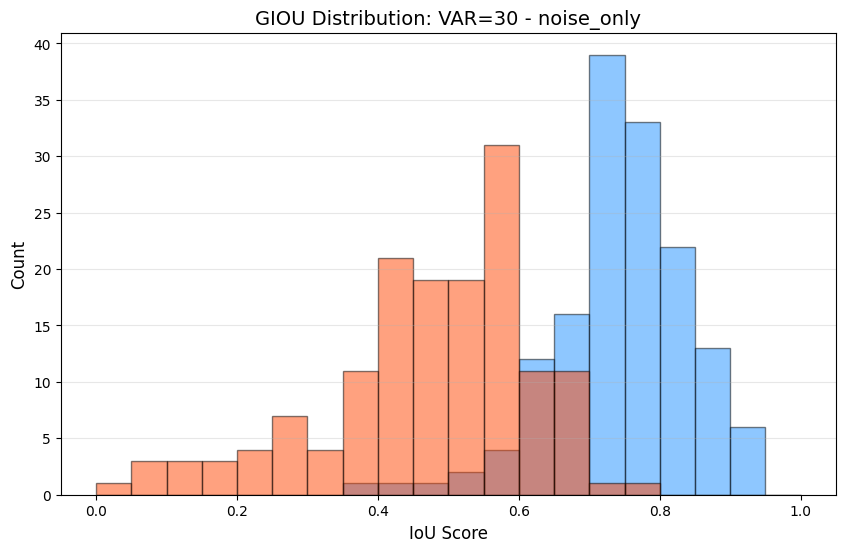

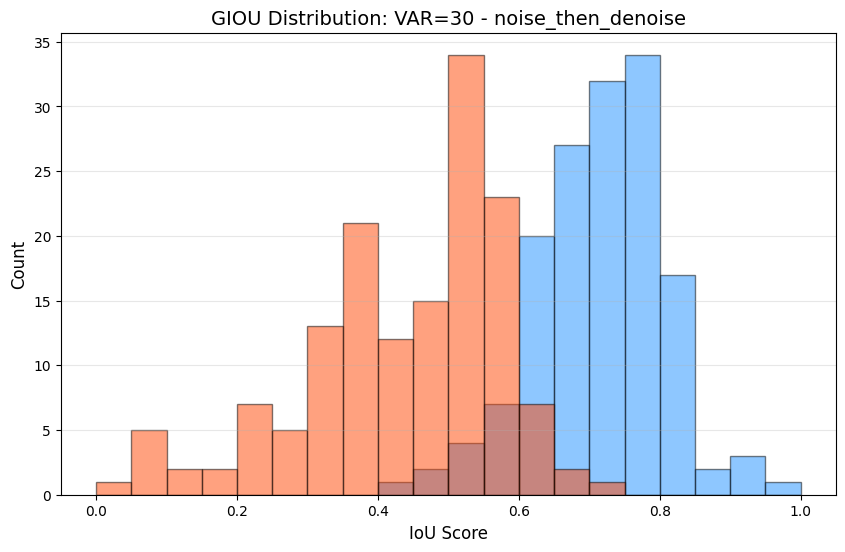

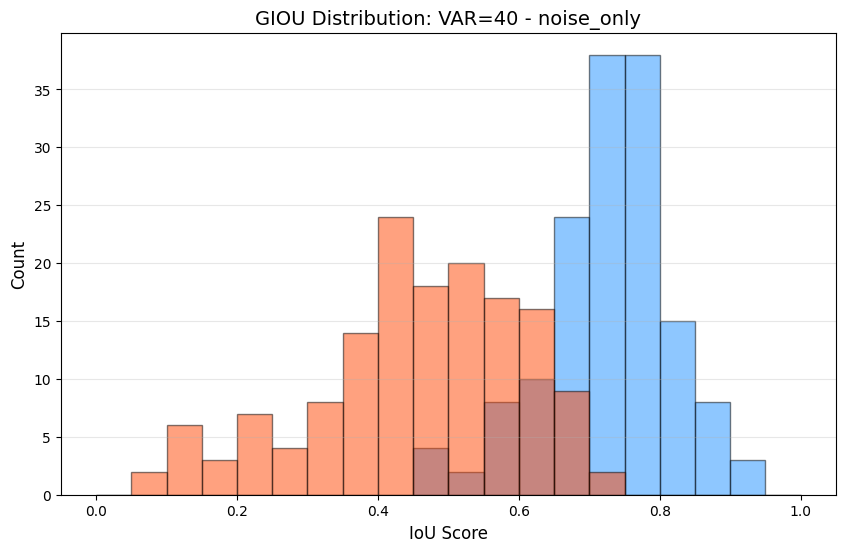

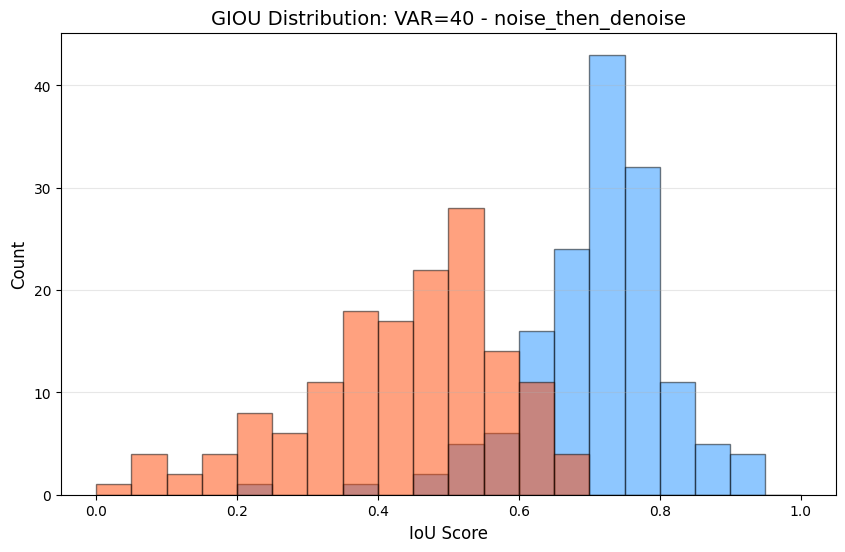

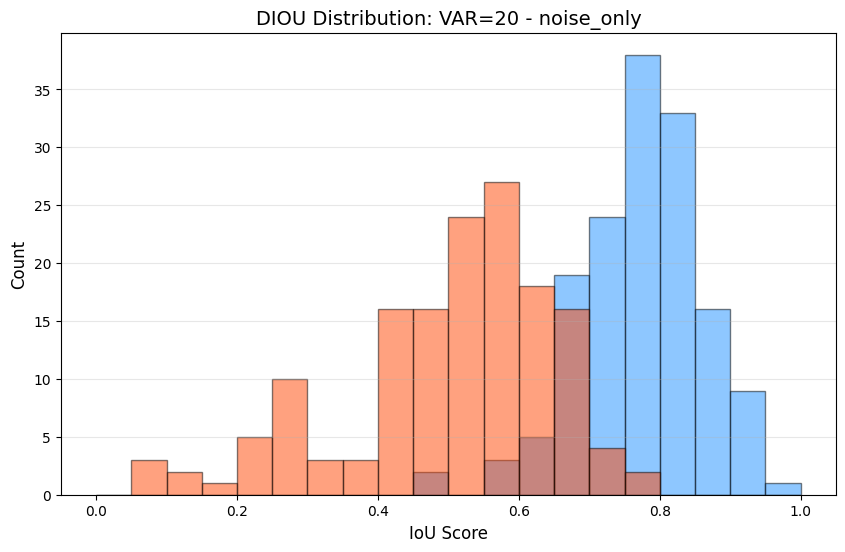

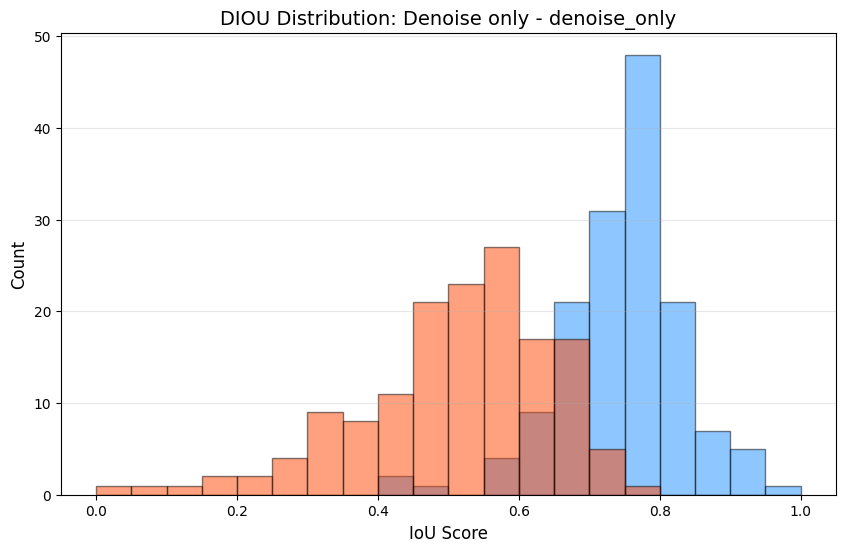

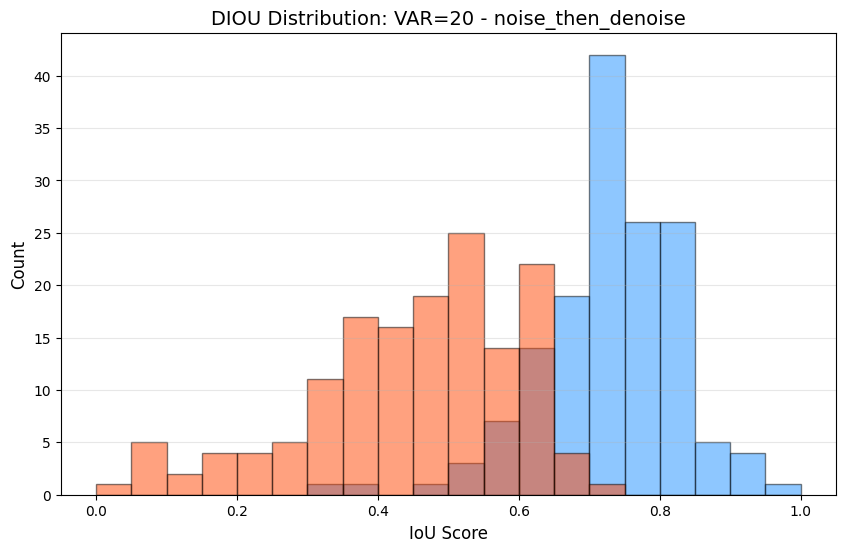

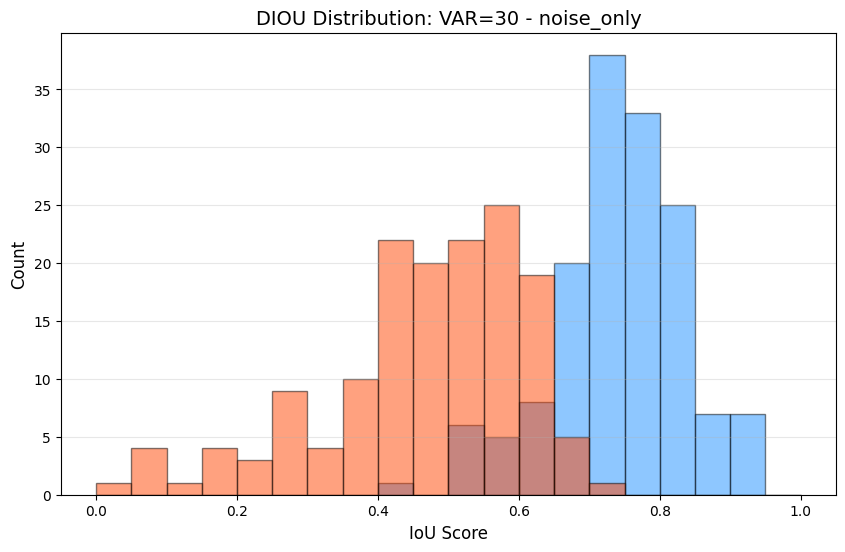

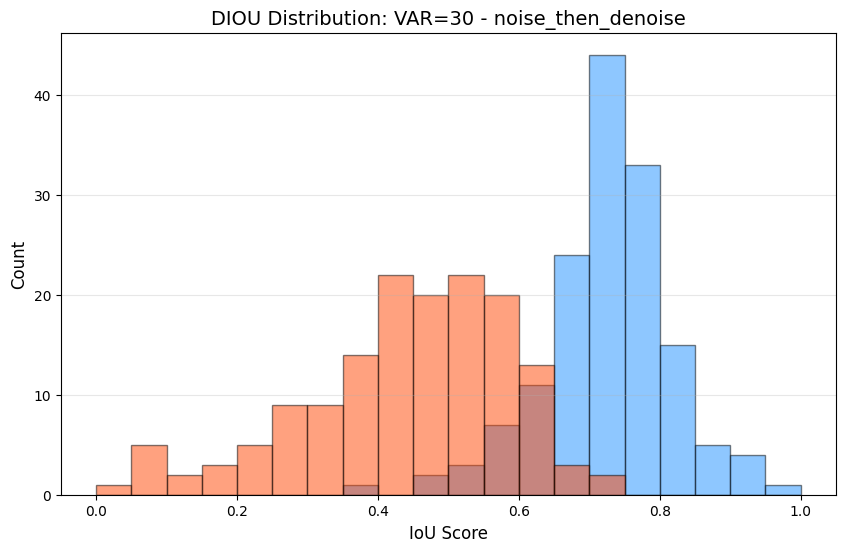

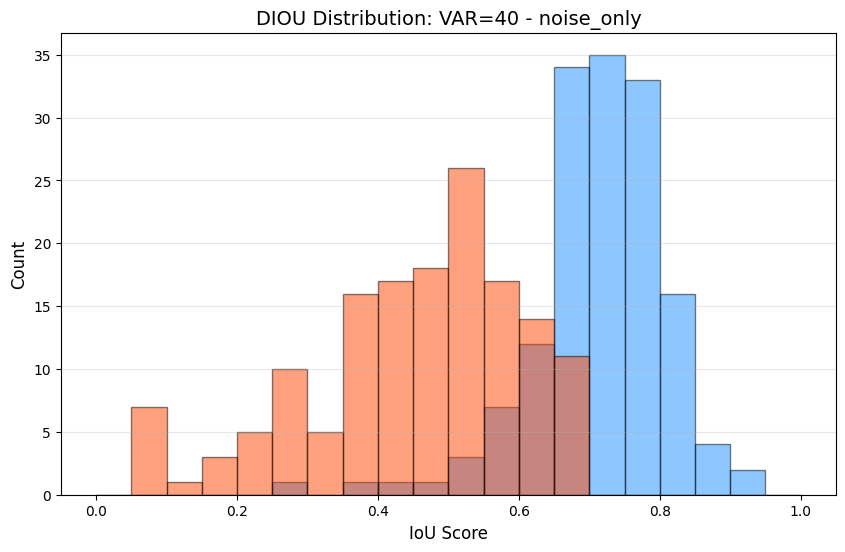

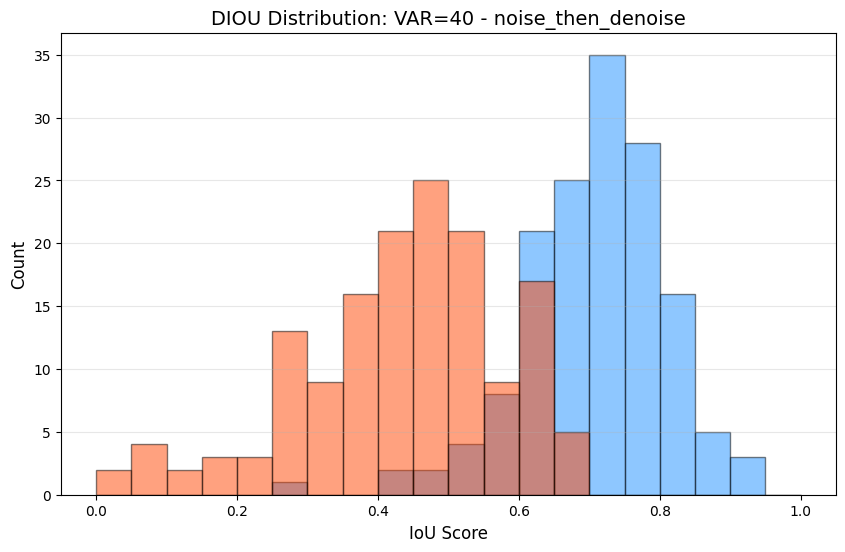

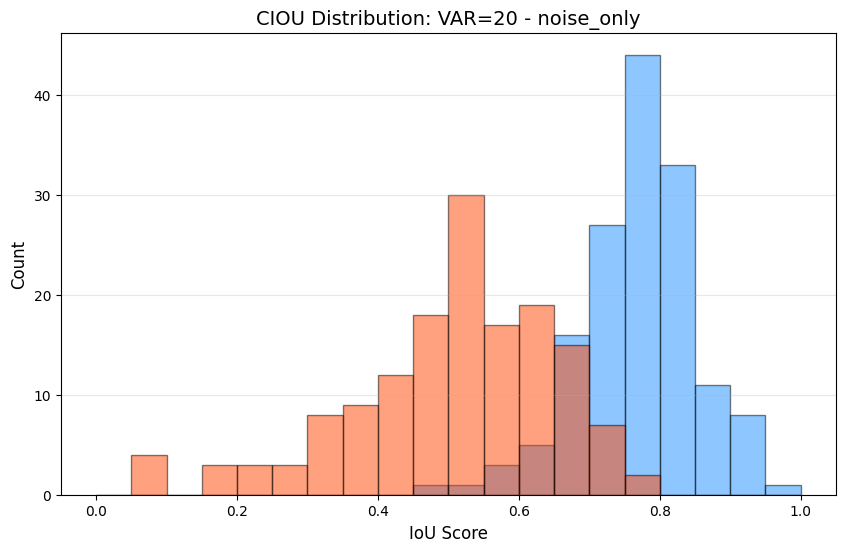

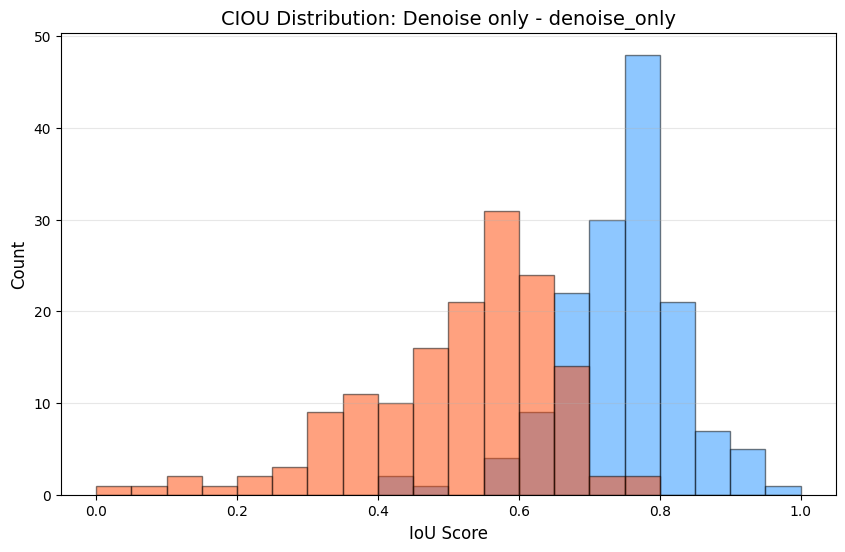

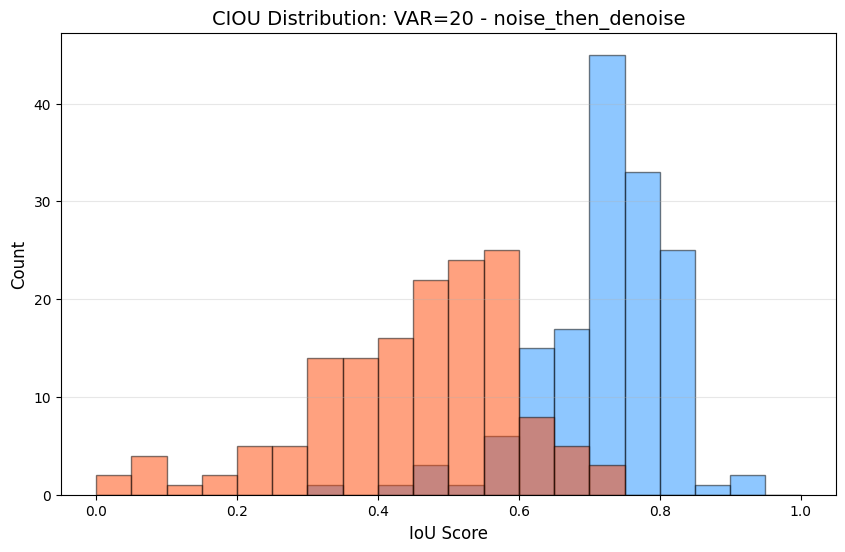

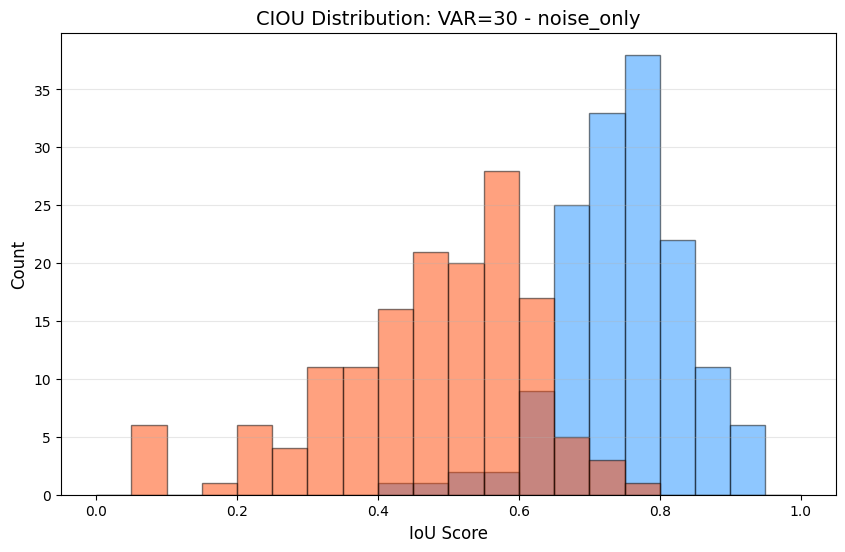

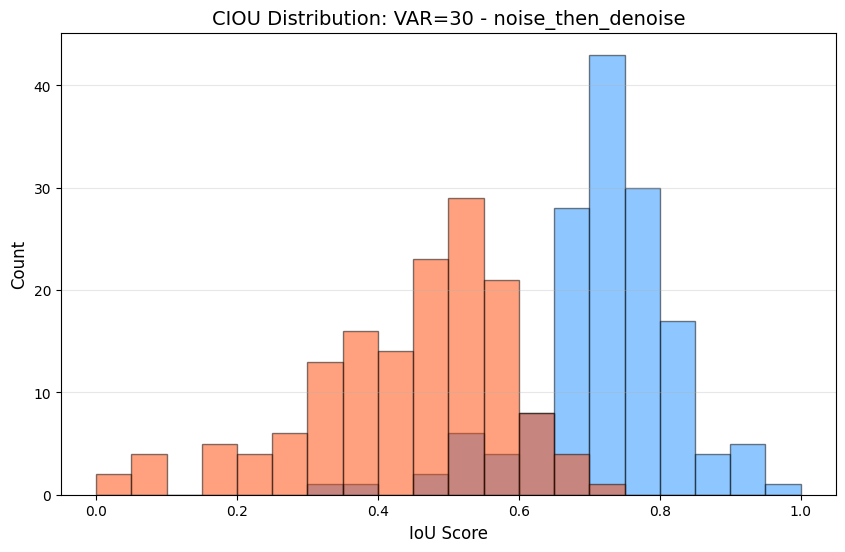

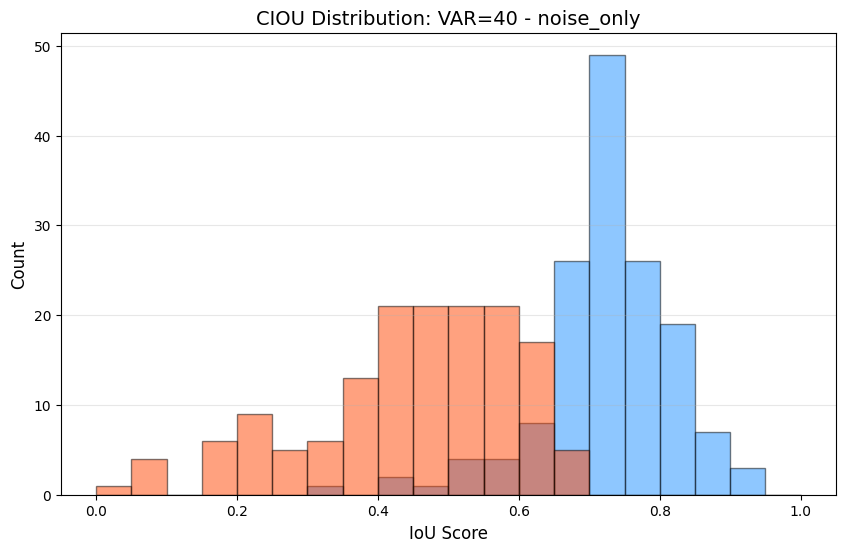

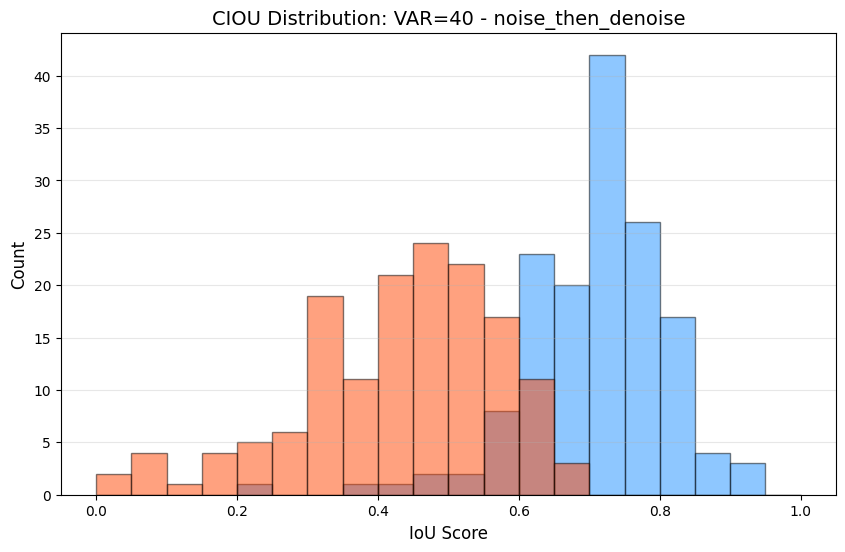

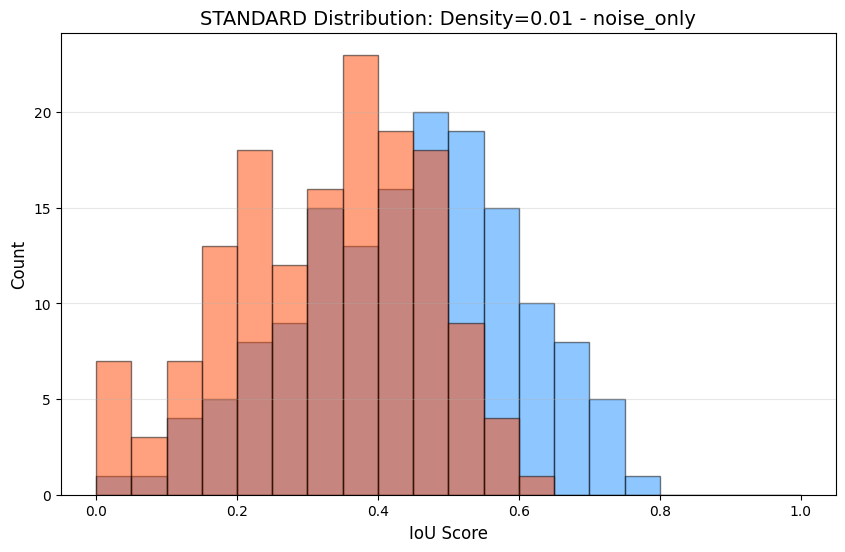

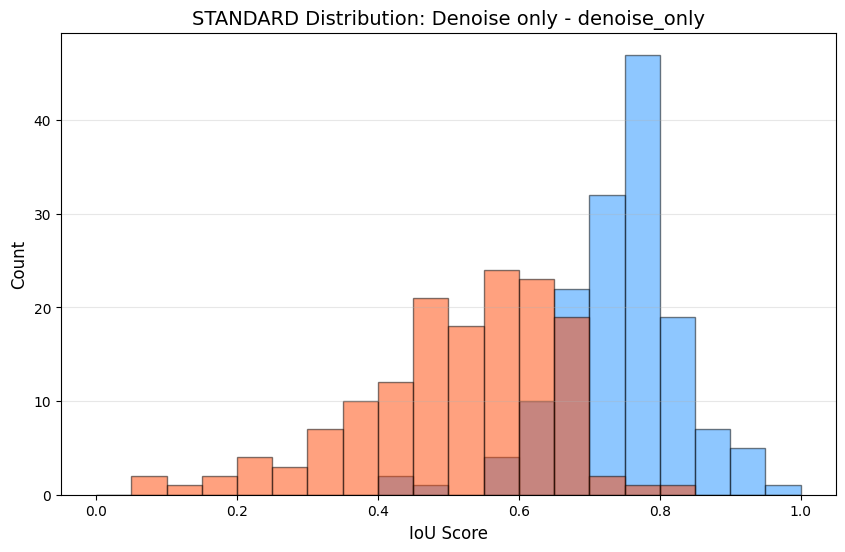

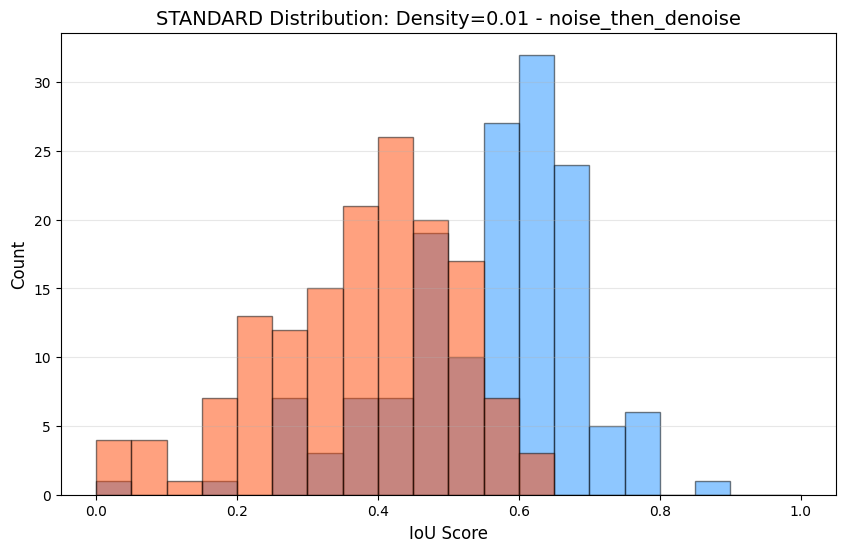

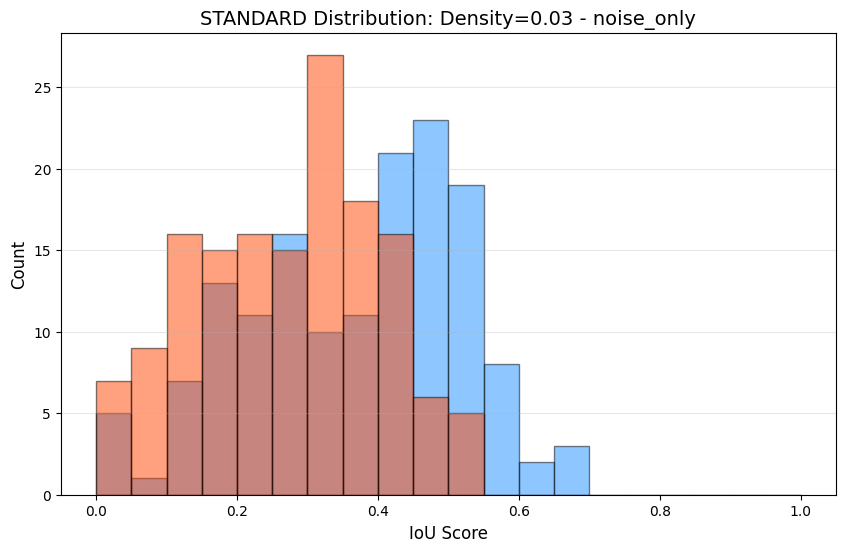

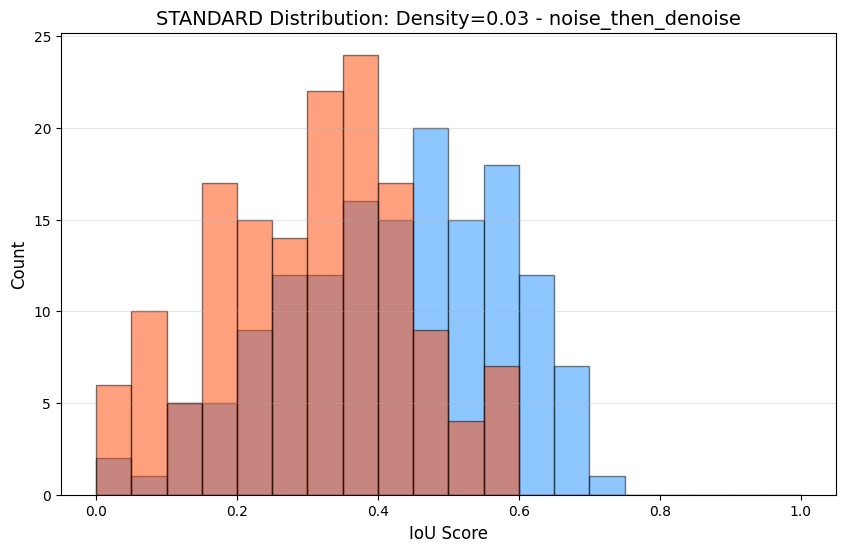

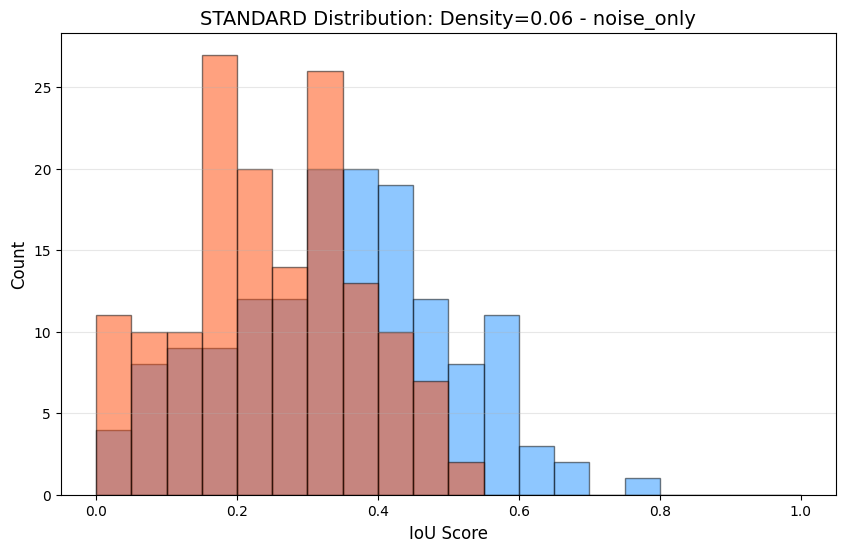

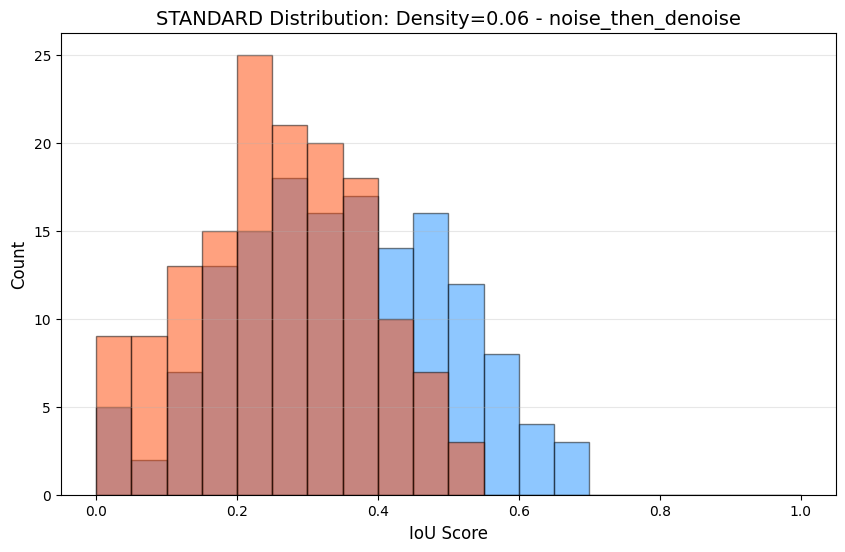

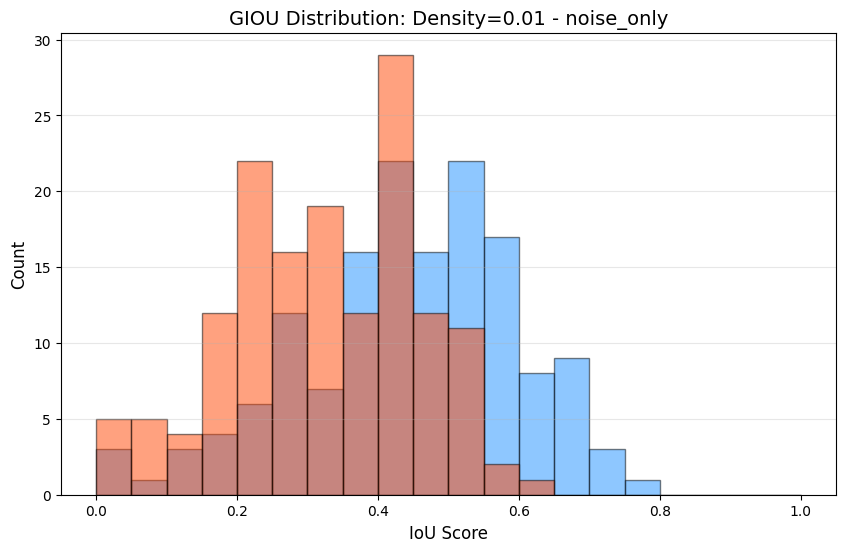

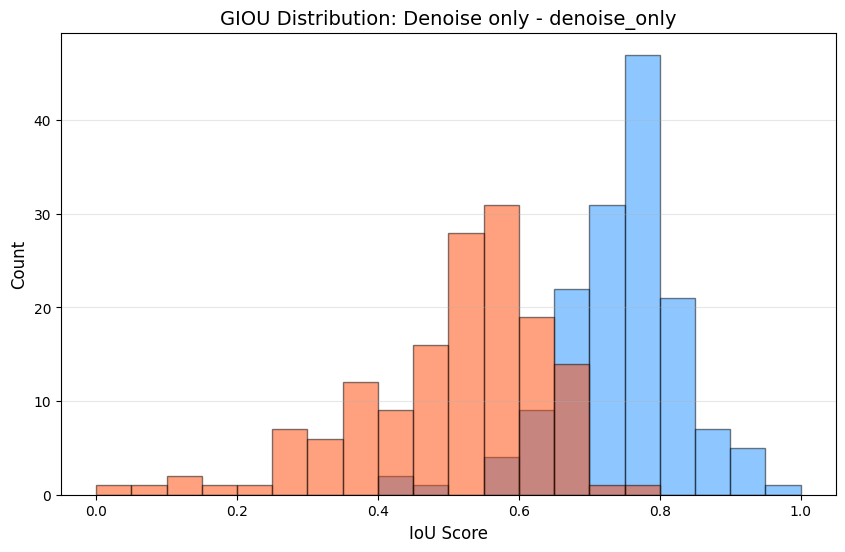

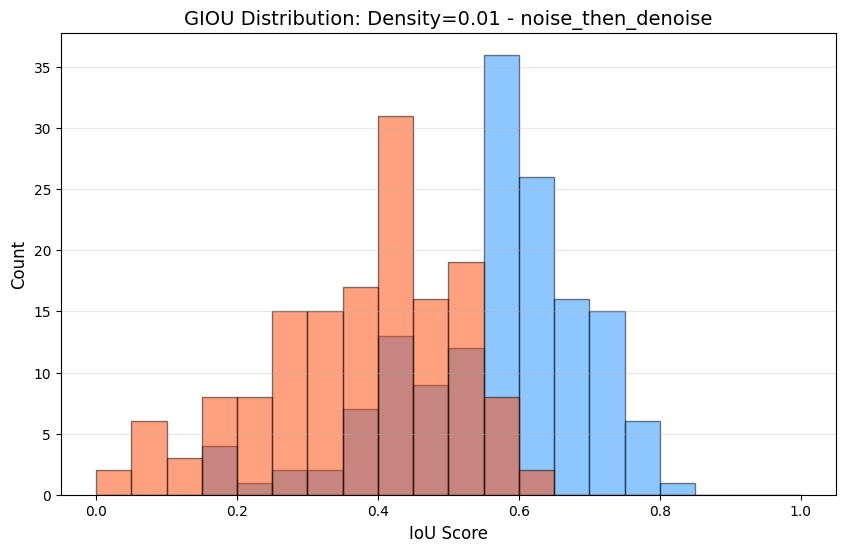

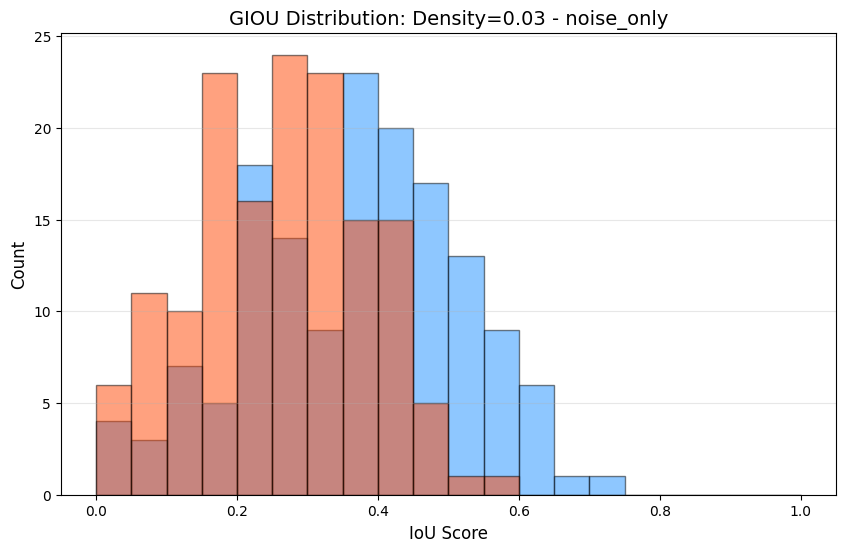

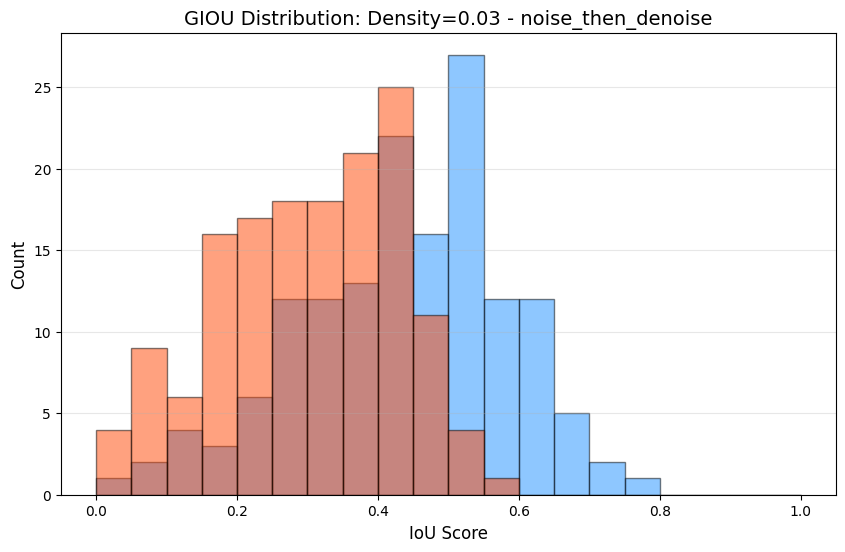

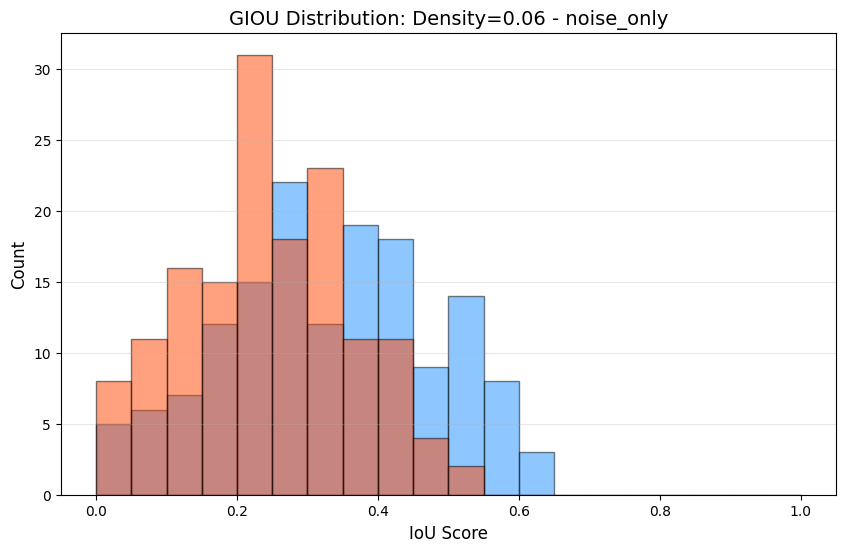

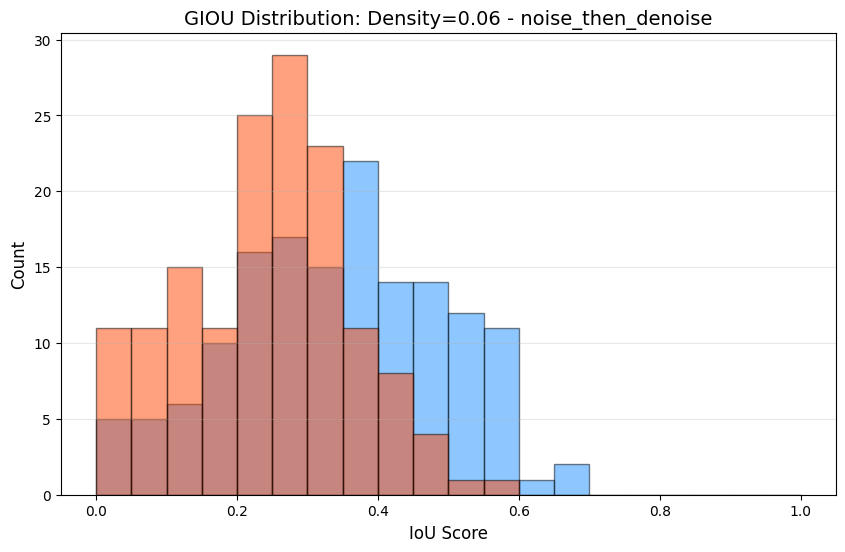

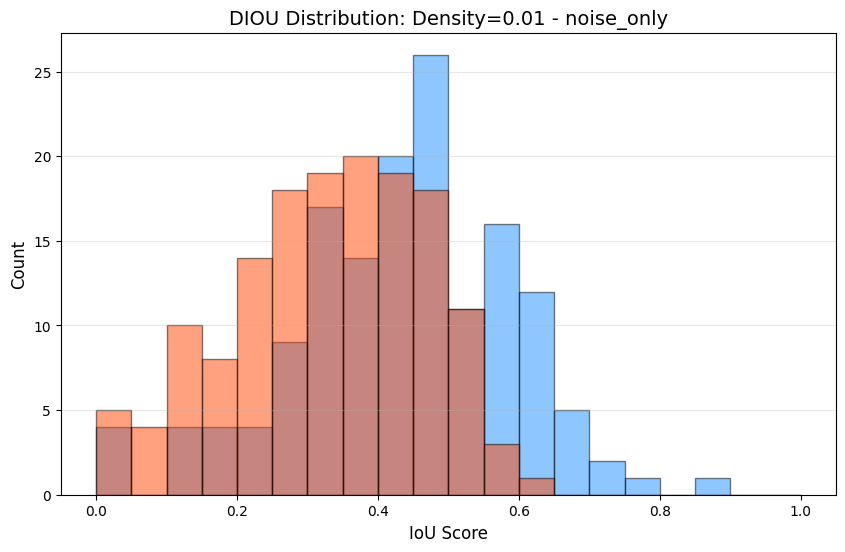

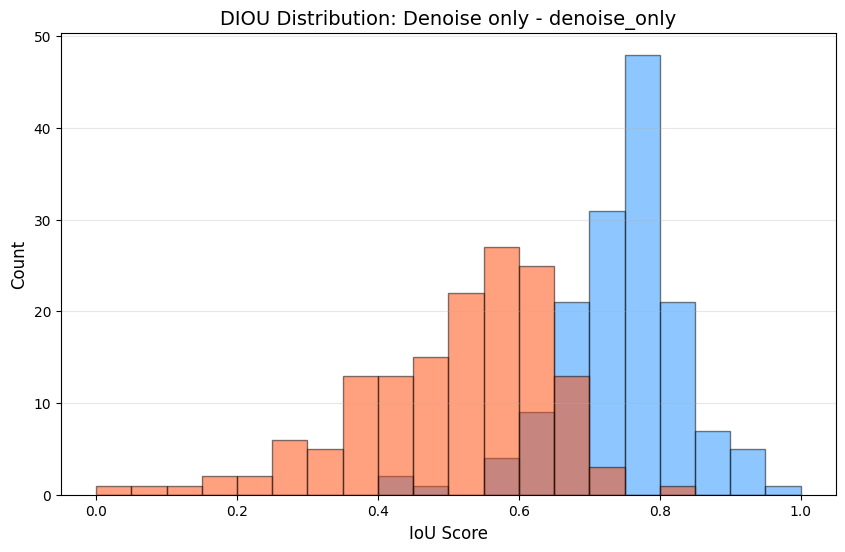

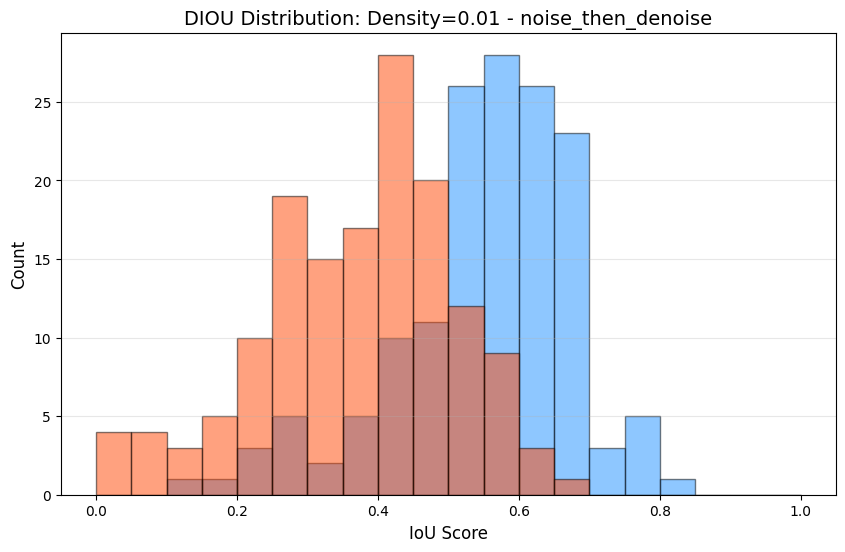

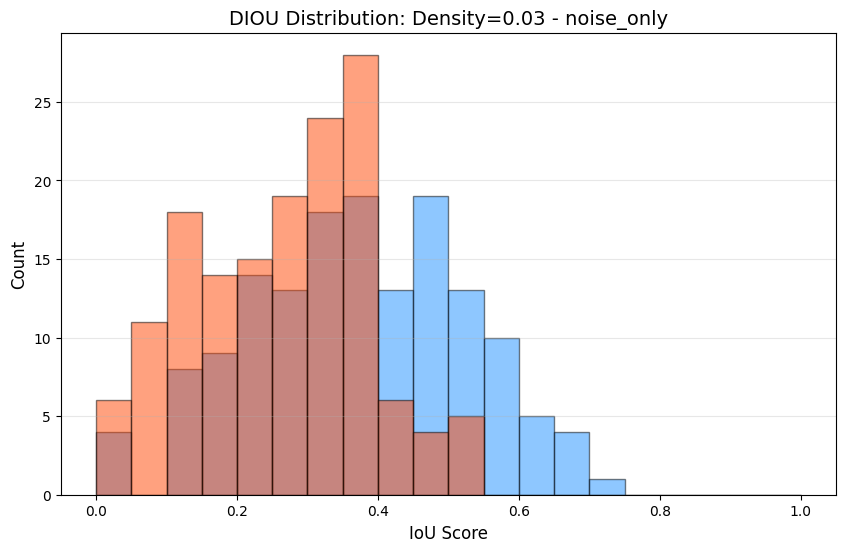

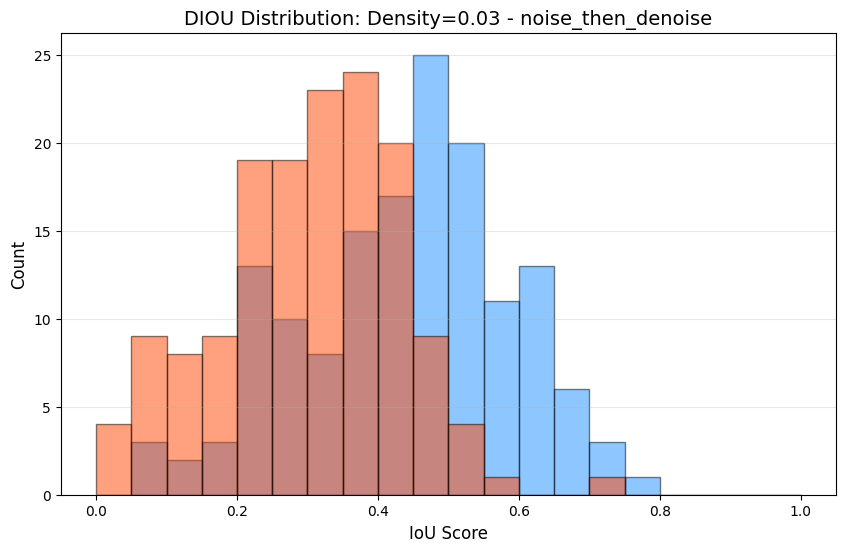

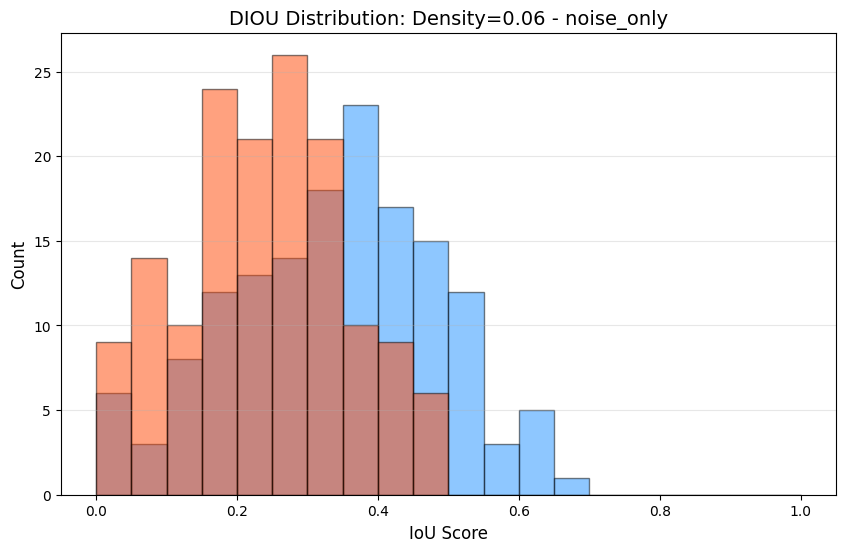

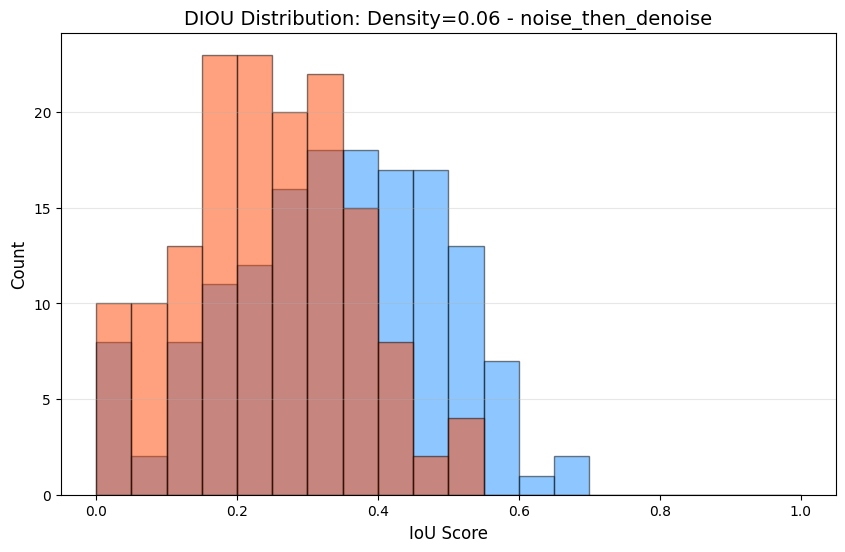

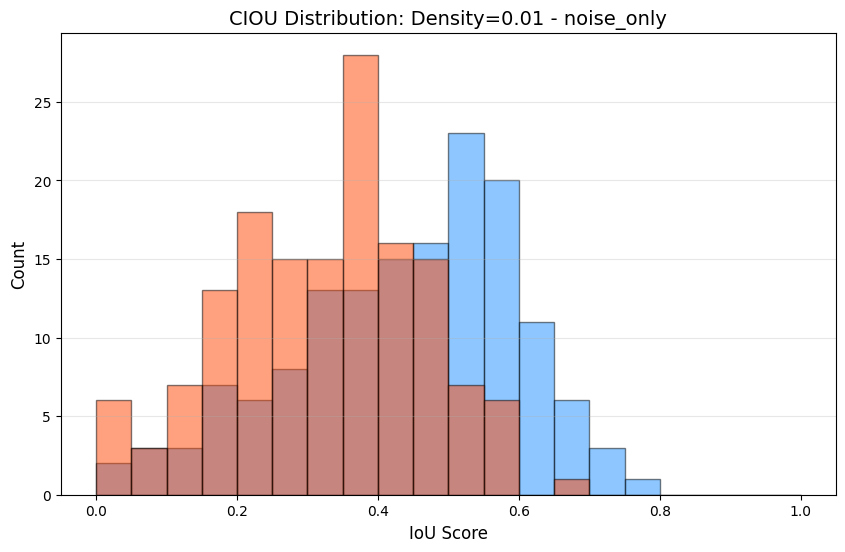

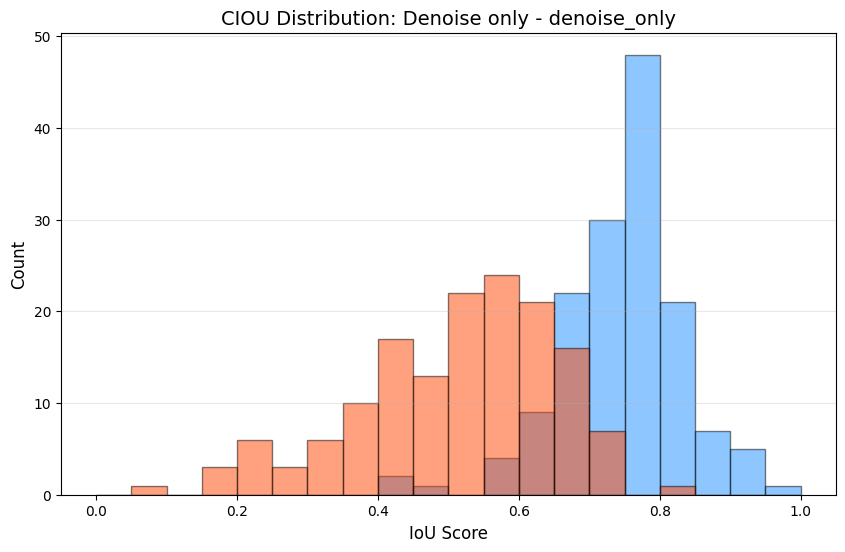

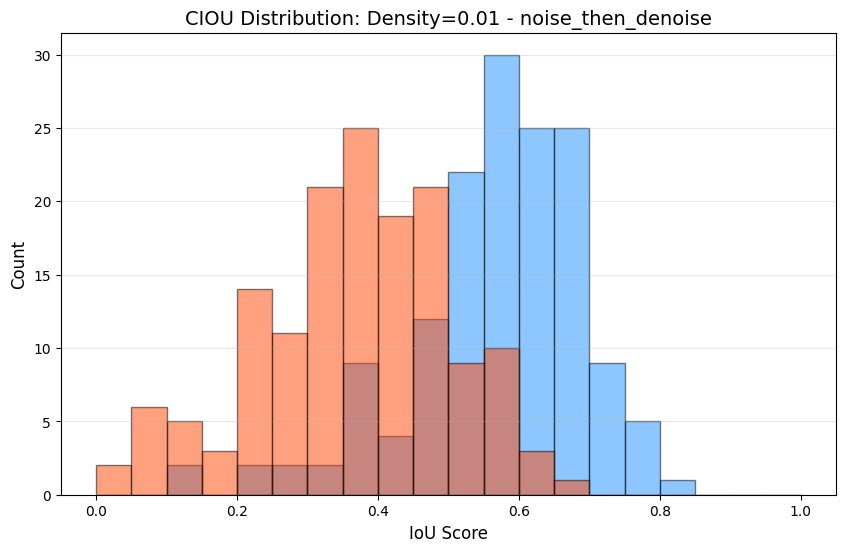

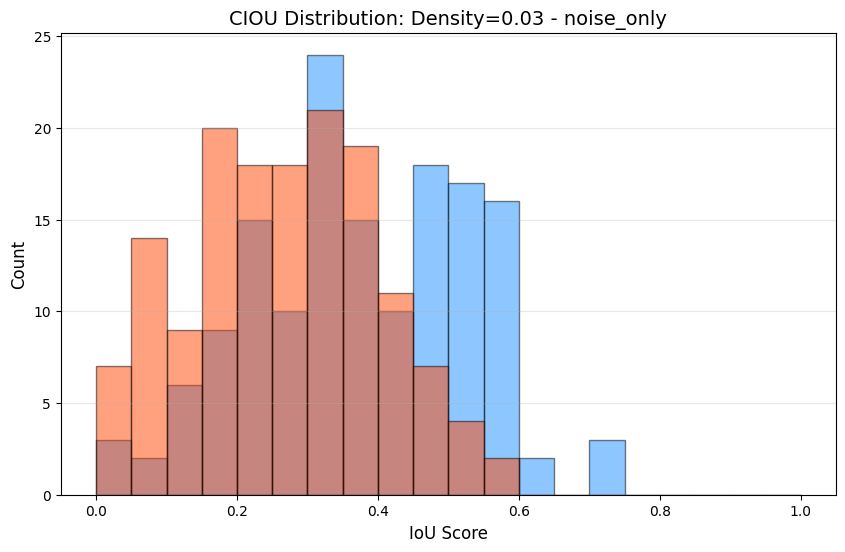

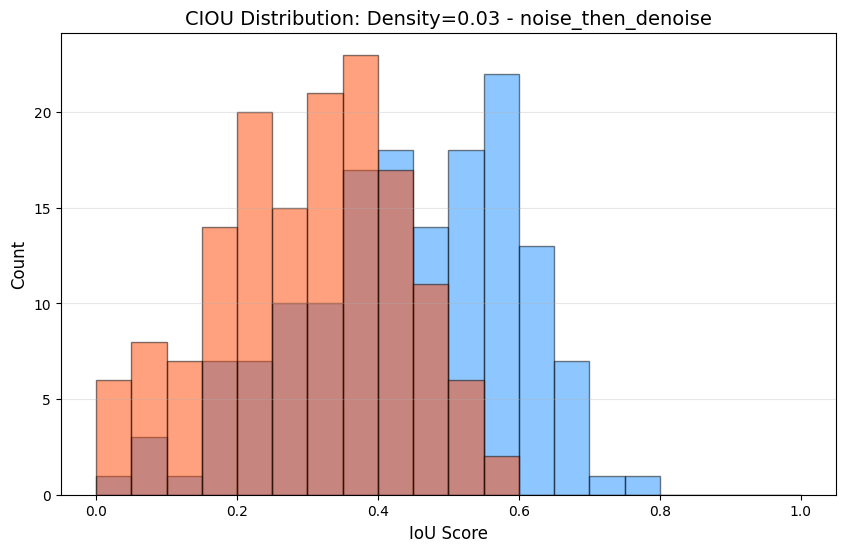

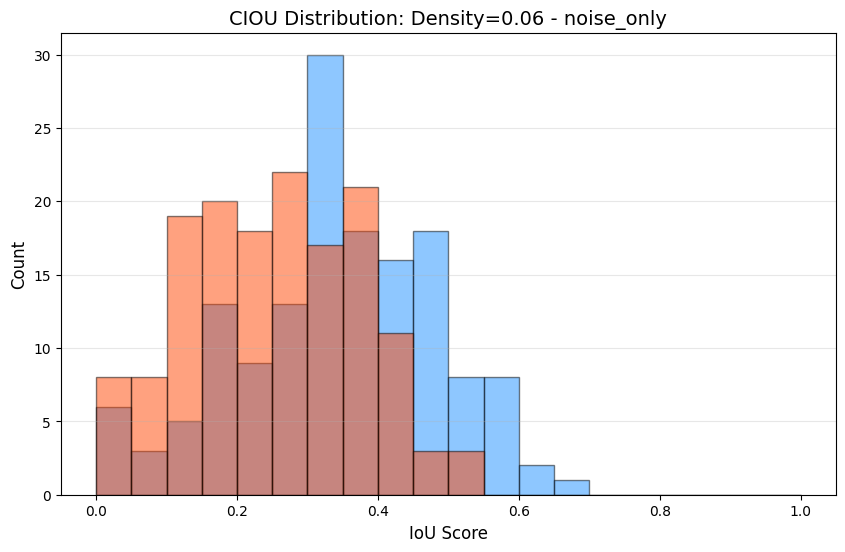

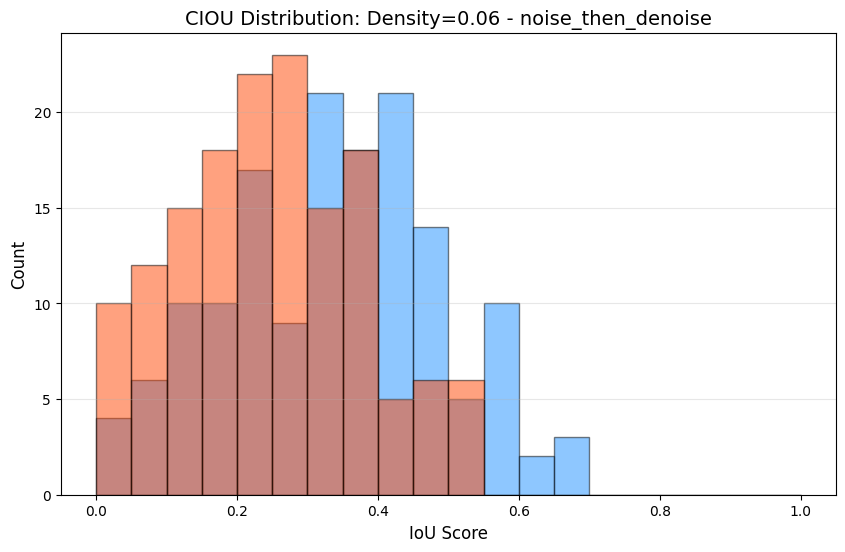

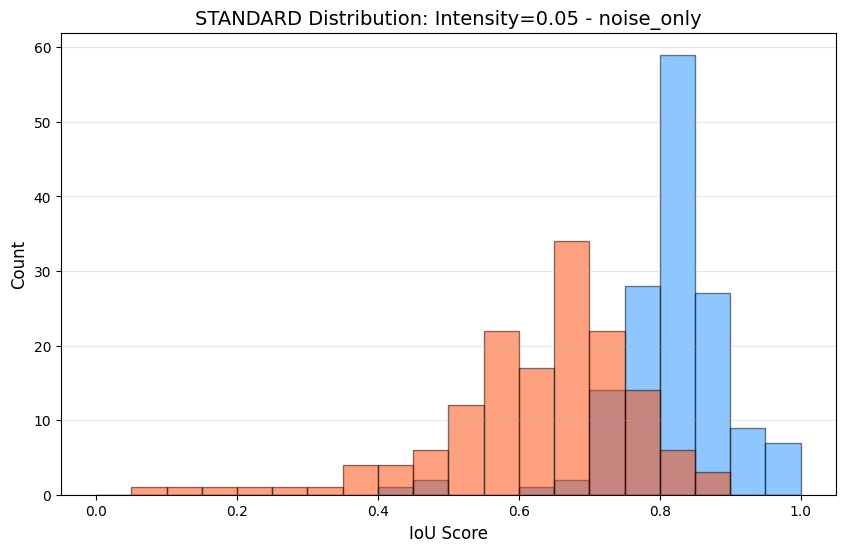

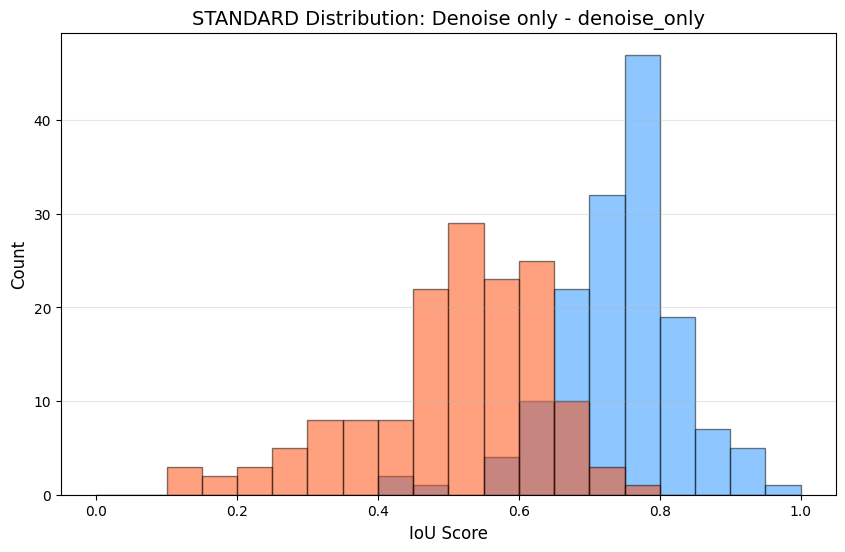

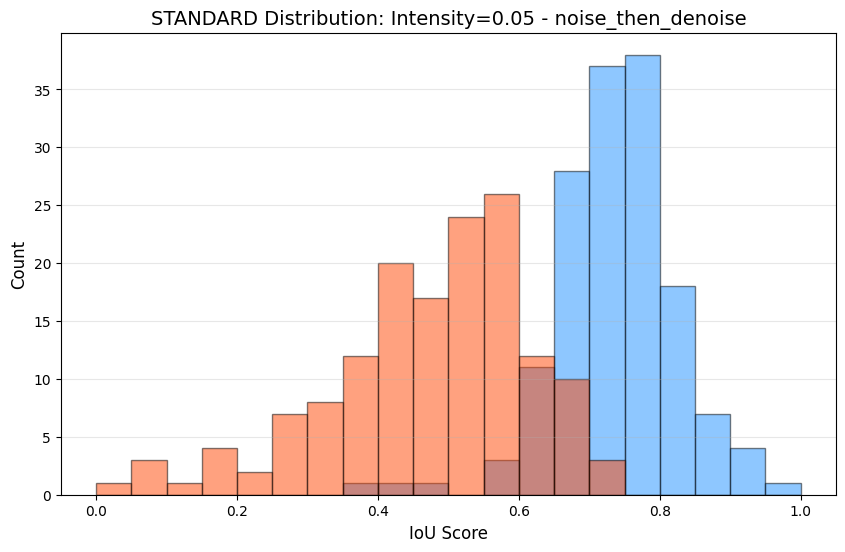

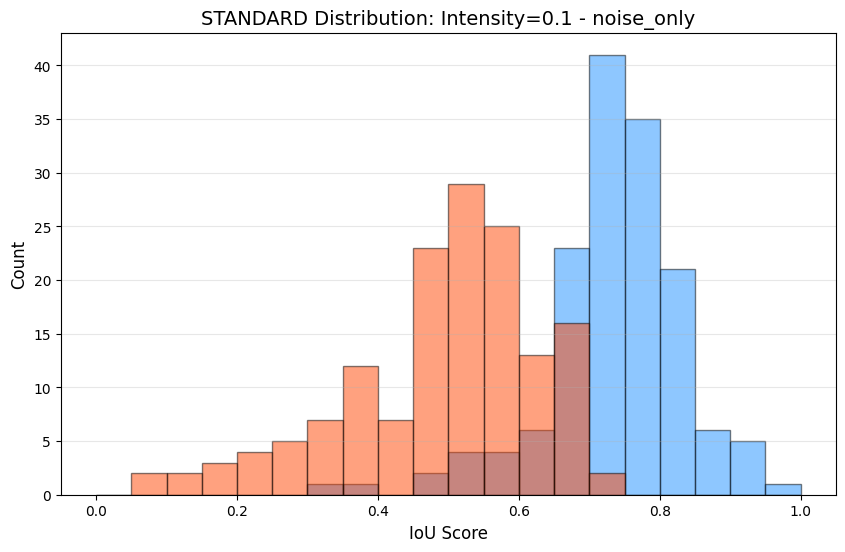

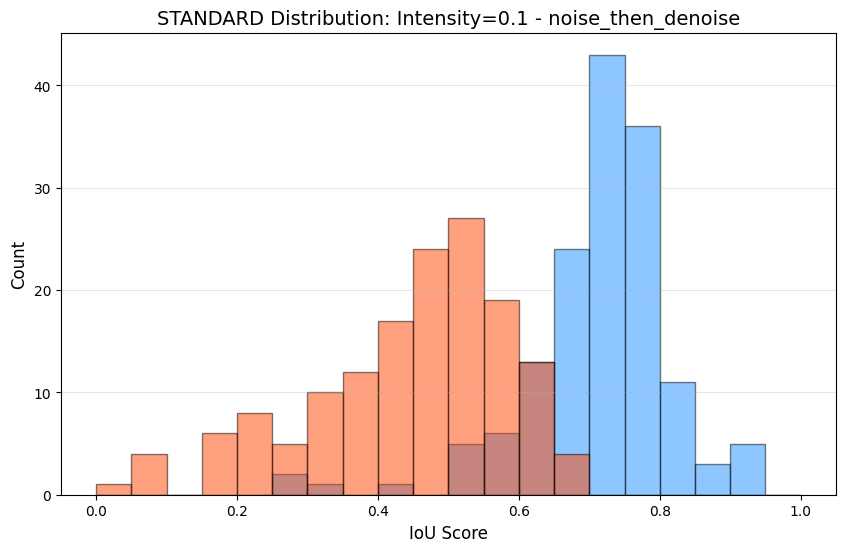

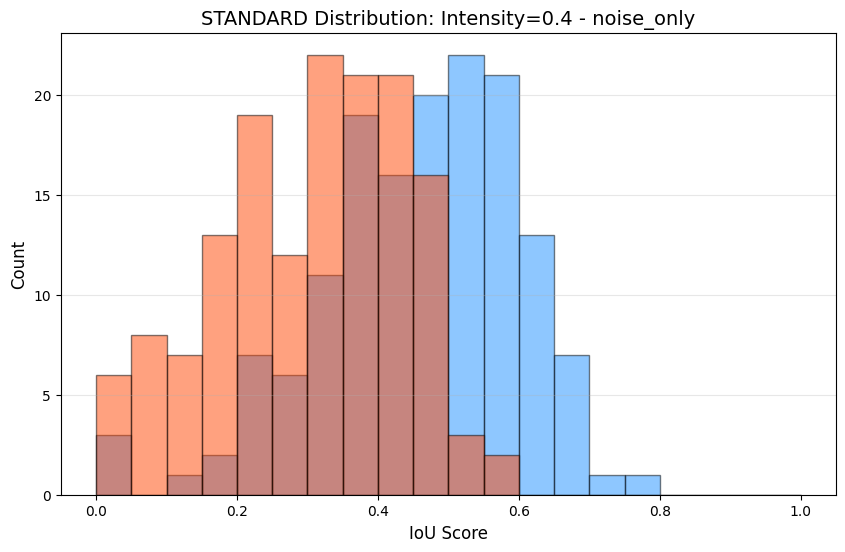

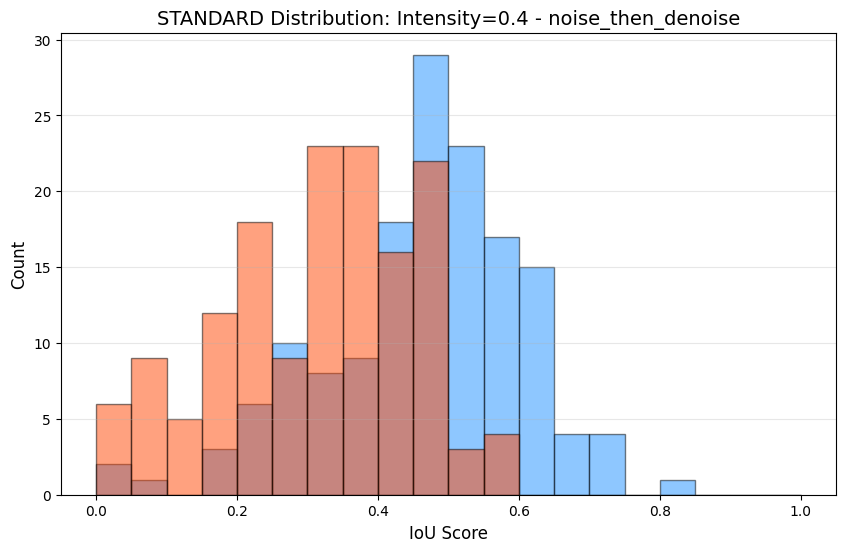

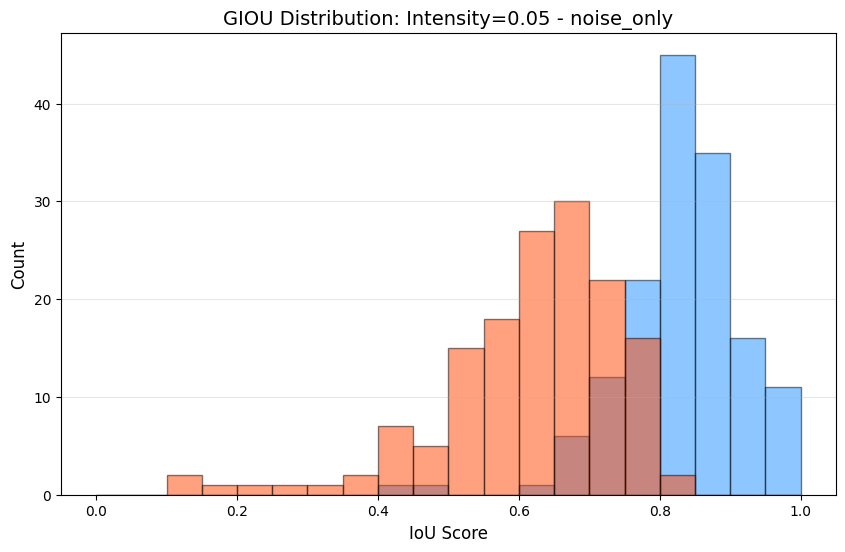

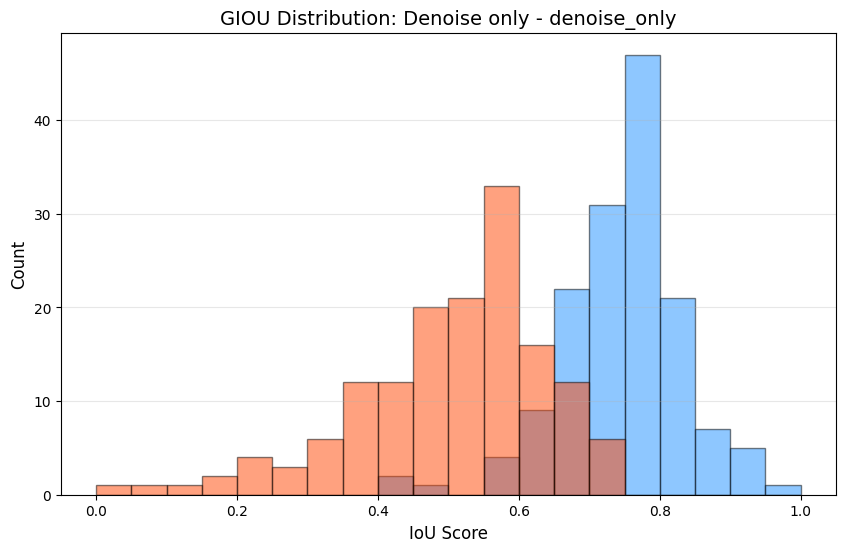

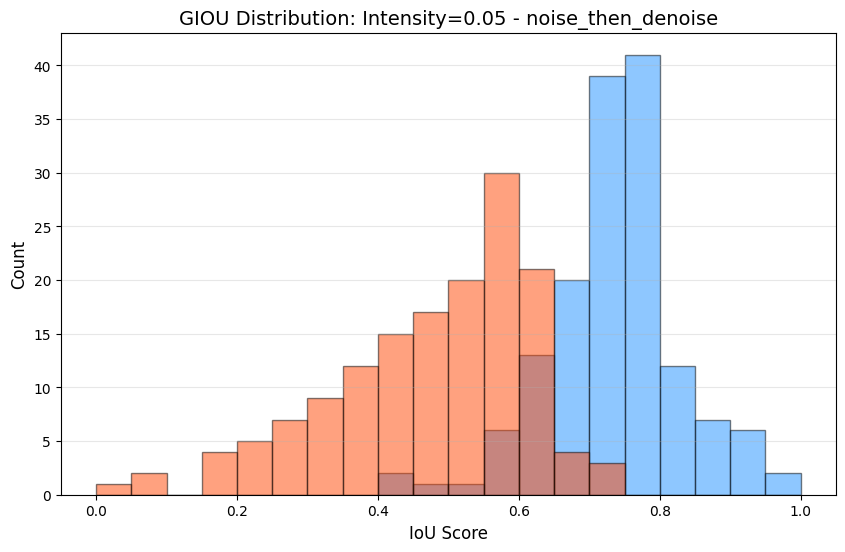

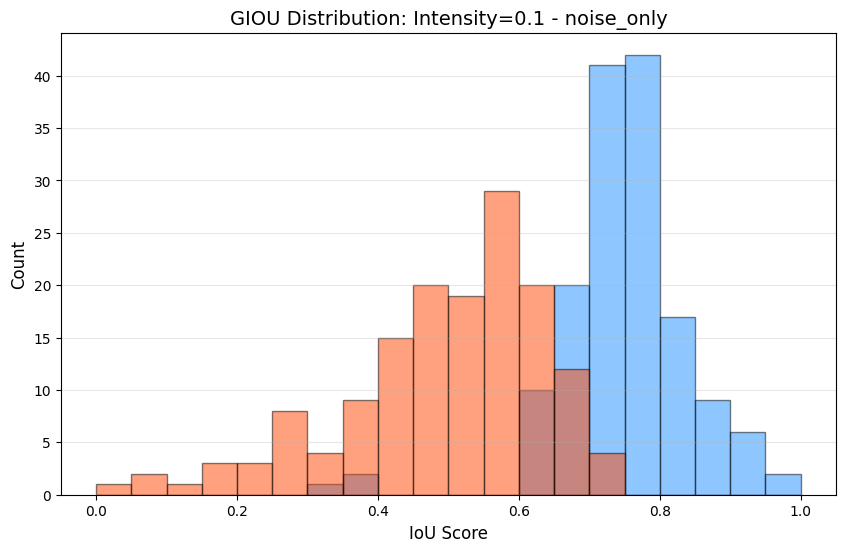

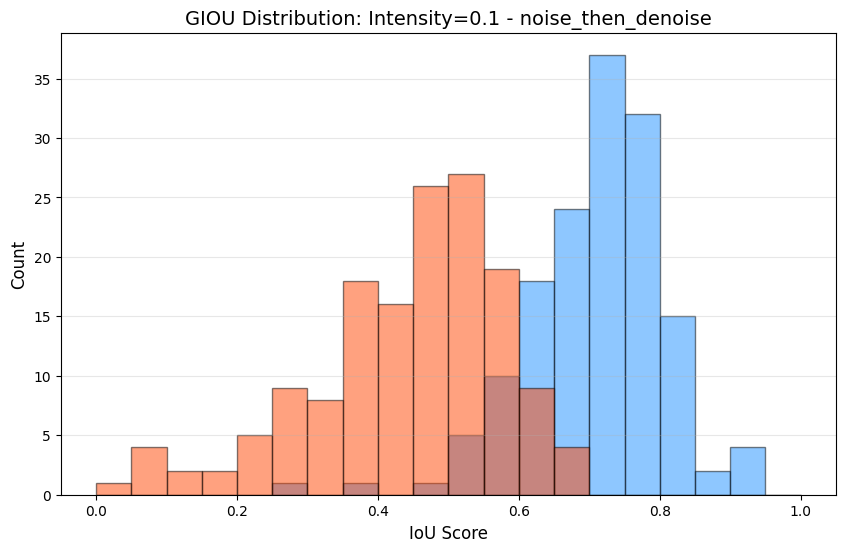

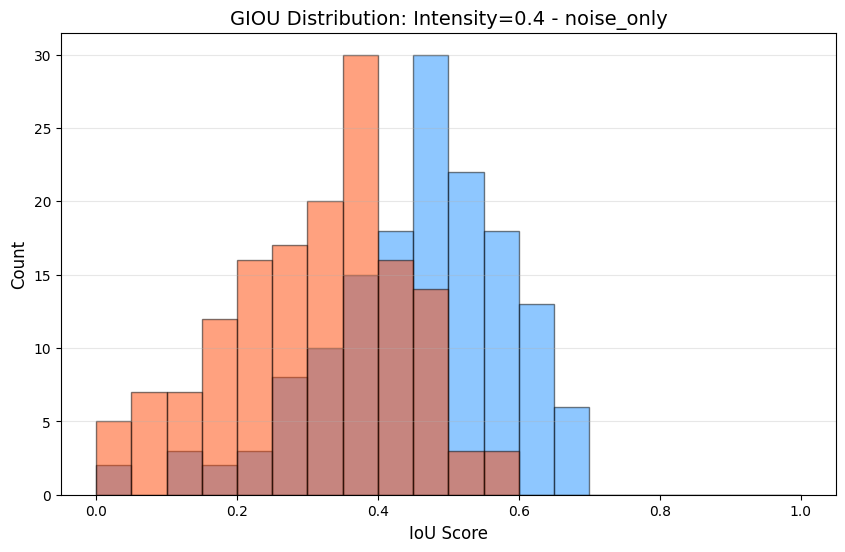

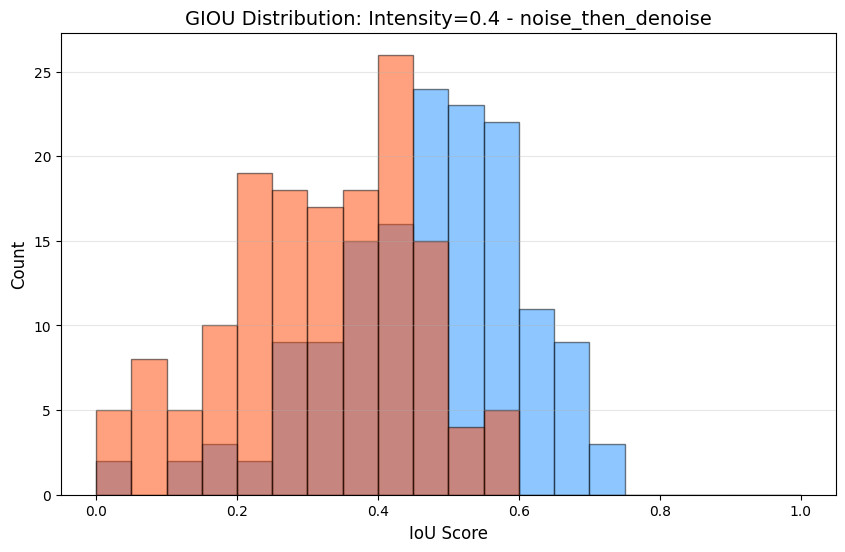

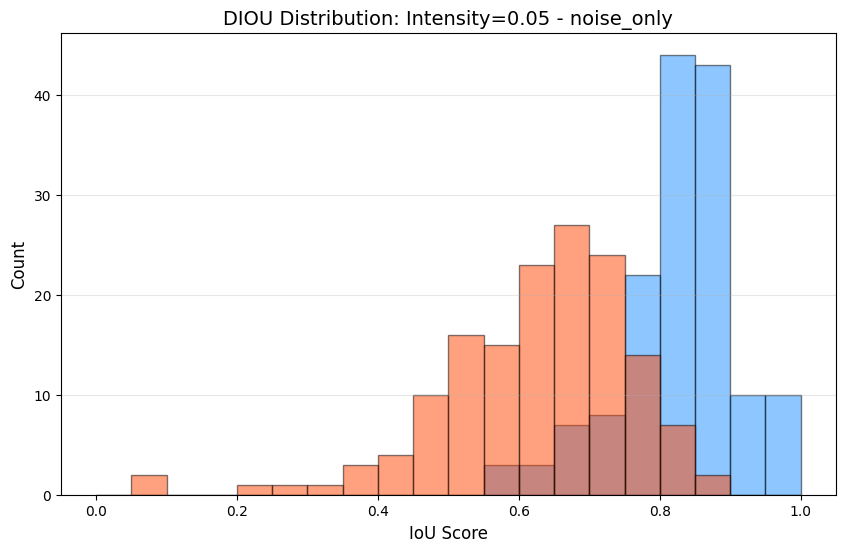

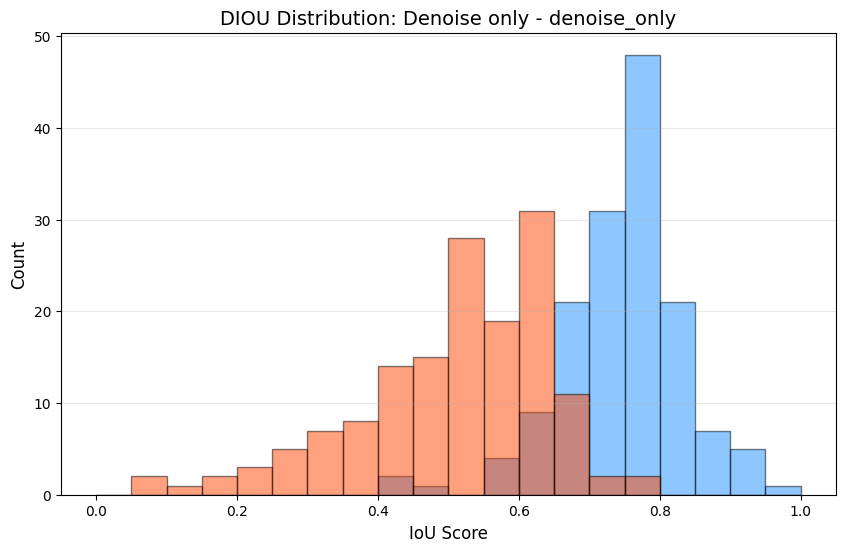

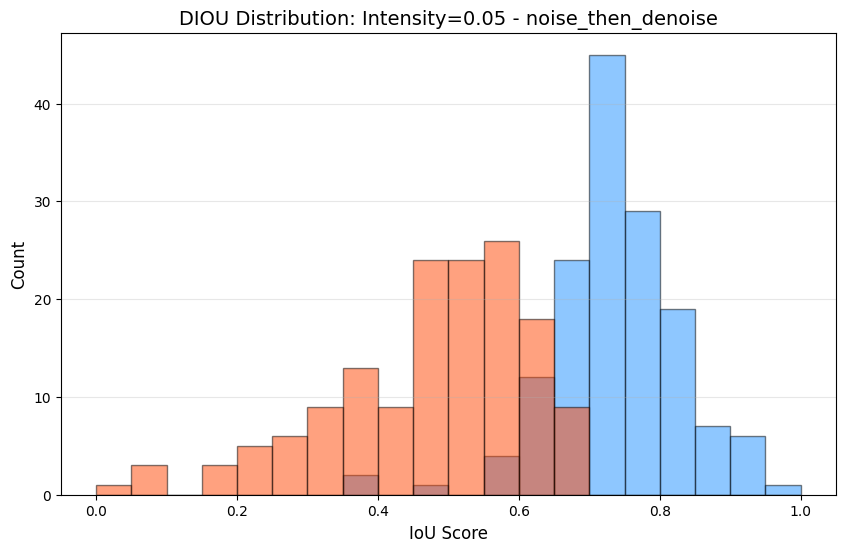

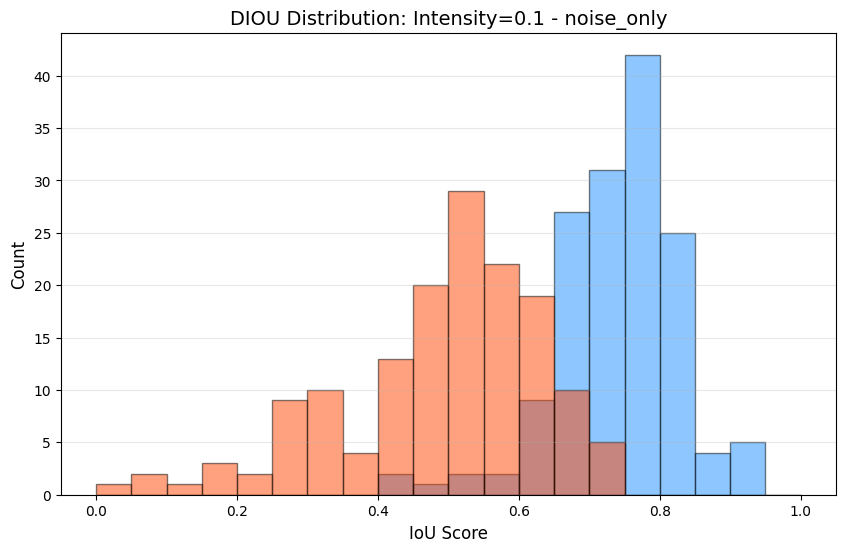

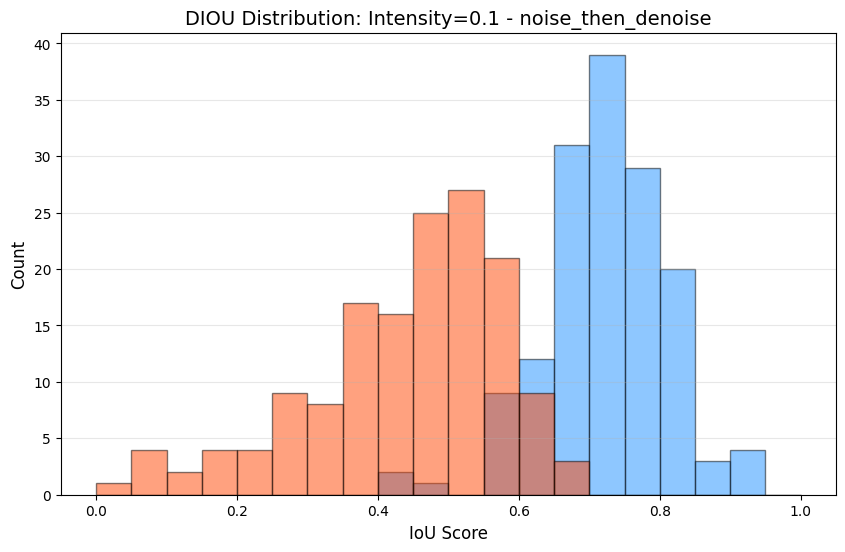

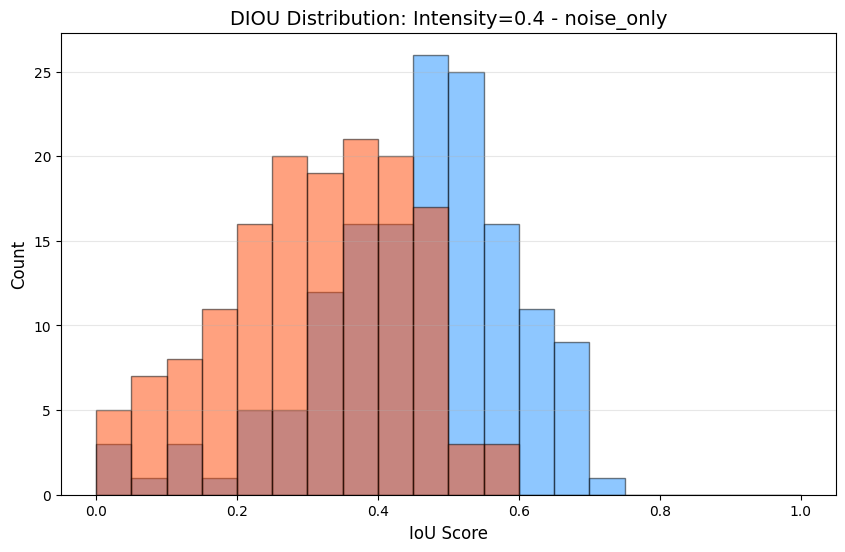

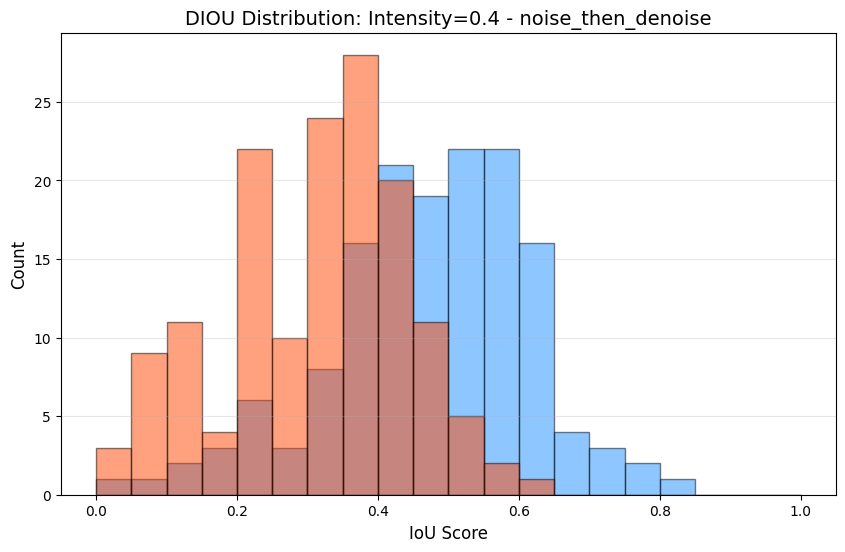

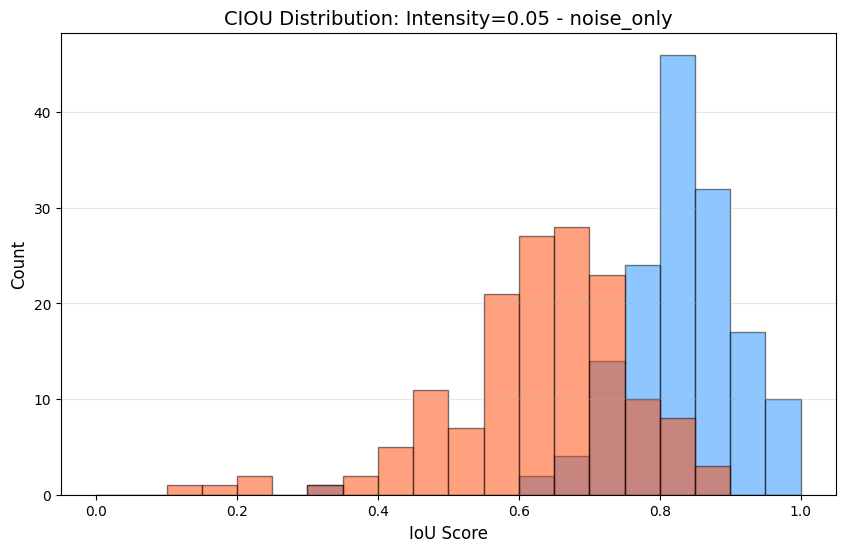

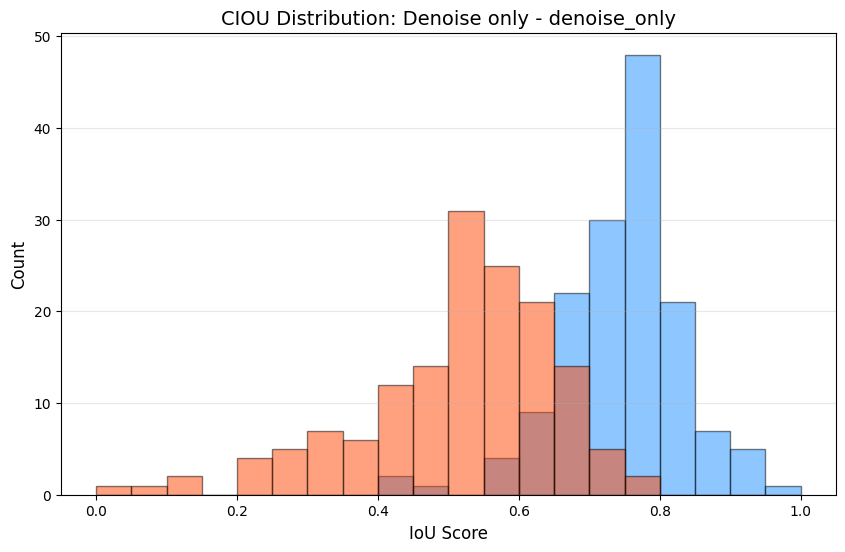

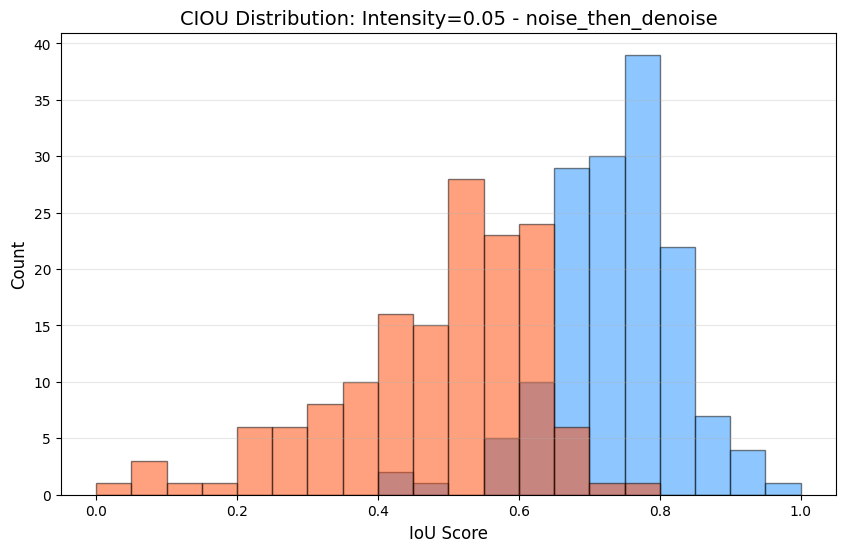

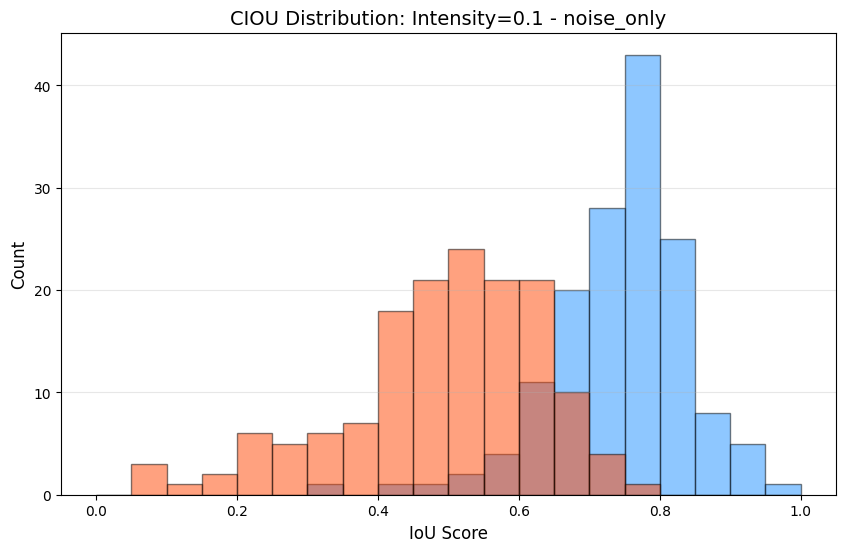

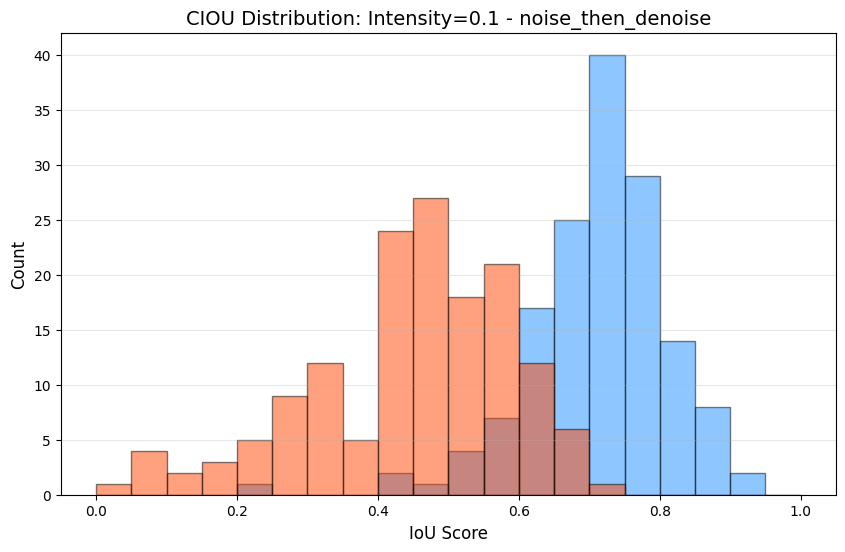

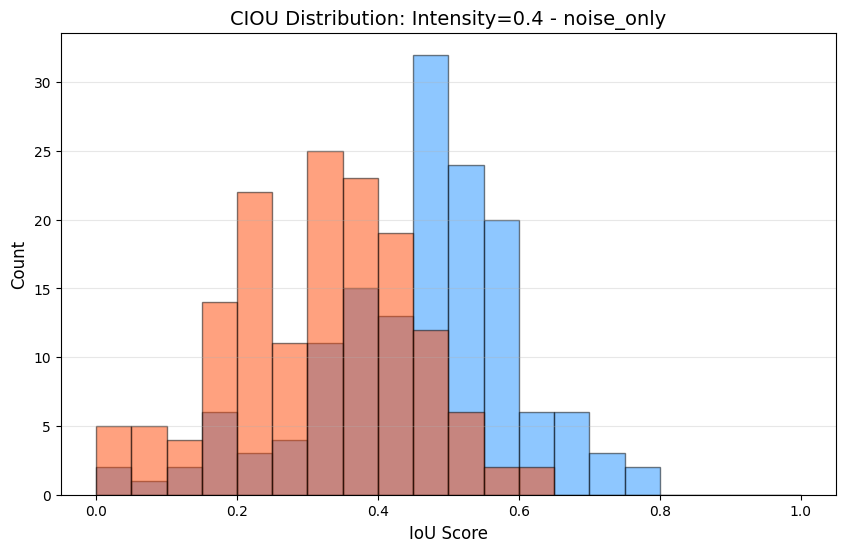

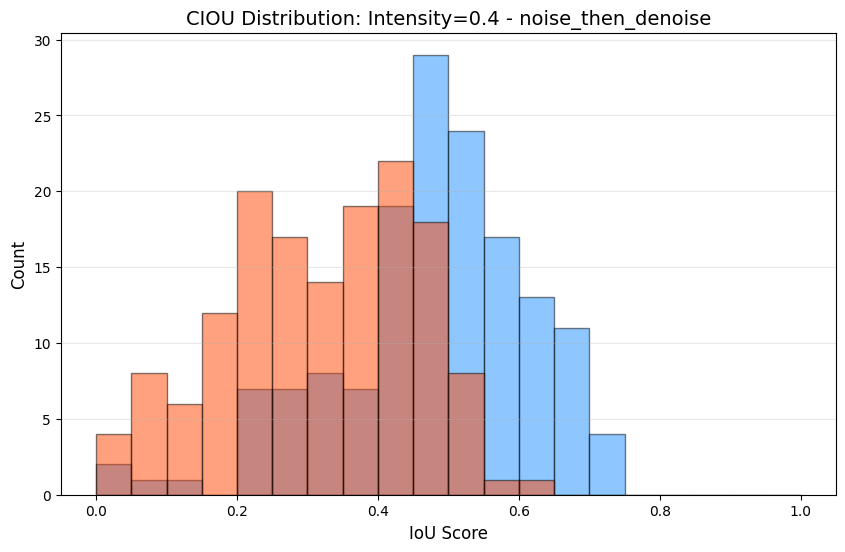

In [19]:
import math

iou_types = ["standard", "giou", "diou", "ciou"]
NUM_ITERATIONS = 5
CONFIDENCE_THRESHOLD = 0.5


noise_configs = [
    {'type': 'poisson', 'scale': 0.1},
    {'type': 'poisson', 'scale': 0.3},
    {'type': 'poisson', 'scale': 0.9}
]
batch_test_with_plots(
    num_iterations=NUM_ITERATIONS,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    test_images=test_images,
    target_class=TARGET_CLASS,
    noise_configs=noise_configs,
    iou_types=iou_types,
    denoiser=denoiser,
    pipelines=PIPELINES
)


noise_configs = [
    {'type': 'gaussian', 'mean': 0, 'std': math.sqrt(20)}, 
    {'type': 'gaussian', 'mean': 0, 'std': math.sqrt(30)},
    {'type': 'gaussian', 'mean': 0, 'std': math.sqrt(40)}  
]
batch_test_with_plots(
    num_iterations=NUM_ITERATIONS,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    test_images=test_images,
    target_class=TARGET_CLASS,
    noise_configs=noise_configs,
    iou_types=iou_types,
    denoiser=denoiser,
    pipelines=PIPELINES
)

noise_configs = [
    {'type': "salt_and_pepper", 'density': 0.01},
    {'type': "salt_and_pepper", 'density': 0.03},
    {'type': "salt_and_pepper", 'density': 0.06}
]
batch_test_with_plots(
    num_iterations=NUM_ITERATIONS,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    test_images=test_images,
    target_class=TARGET_CLASS,
    noise_configs=noise_configs,
    iou_types=iou_types,
    denoiser=denoiser,
    pipelines=PIPELINES
)

noise_configs = [
    {'type': 'speckle', 'intensity': 0.05},
    {'type': 'speckle', 'intensity': 0.1},
    {'type': 'speckle', 'intensity': 0.4}
]

batch_test_with_plots(
    num_iterations=NUM_ITERATIONS,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    test_images=test_images,
    target_class=TARGET_CLASS,
    noise_configs=noise_configs,
    iou_types=iou_types,
    denoiser=denoiser,
    pipelines=PIPELINES

)
